In [2]:
import plotnado.api as pn
import coolbox.api as cb
import pathlib
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import pyranges as pr
import numpy as np
import re
from typing import List, Dict, Any, Tuple, Union, Literal, Optional

In [3]:
from plotnado.api import Figure, TrackWrapper, HighlightsFromFile

In [4]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["svg.fonttype"] = "none"

## Highlight the 'unique' enhancers

### Peaks

In [5]:
df_en_all = pd.read_csv(
    "/home/a/asmith/project_milne_group/Projects/2023-11-21-MLL-AF4_transcriptional_heterogeneity_paper/mll-af4_transcriptional_heterogeneity_paper/data/processed/find-enhancer-regions-in-patients/differential_enhancers.csv"
)

In [6]:
df_en_all.head()

,peak,bw1,is_higher,count,Chromosome,Start,End
0,chr12:9778941-9797455,chALL-26754-CM_H3K27ac.bw,True,8,chr12,9778941,9797455
1,chr2:43684095-43685551,CM-iALL87495_H3K27ac.bw,True,8,chr2,43684095,43685551
2,chr21:22960245-22962540,CM-iALL87495_H3K27ac.bw,True,8,chr21,22960245,22962540
3,chr2:2057650-2061569,CM-iALL87495_H3K27ac.bw,True,8,chr2,2057650,2061569
4,chr12:126965439-126967375,chALL-26754-CM_H3K27ac.bw,True,8,chr12,126965439,126967375


### All Enhancers

In [7]:
gr_peaks = pr.read_gtf(
    "/home/a/asmith/project_milne_group/Projects/enhancer_heterogeneity_paper/notebooks/classify_enhancers/gr_h3k27ac_consensus.gtf"
)

gr_peaks = gr_peaks.df[["Chromosome", "Start", "End", "Name"]].pipe(pr.PyRanges)
gr_peaks.df.shape

(13820, 4)

In [8]:
gr_peaks.df.assign(Name=" ")[["Chromosome", "Start", "End"]].to_csv(
    "peaks.bed", index=False, sep="\t", header=False
)

### Filter

In [9]:
df_en = df_en_all.query("count >= 7 and bw1.str.contains('26754')").sort_values(
    ["count", "bw1", "peak"], ascending=[False, True, True]
)
df_en

,peak,bw1,is_higher,count,Chromosome,Start,End
34,chr12:126949140-126951153,chALL-26754-CM_H3K27ac.bw,True,8,chr12,126949140,126951153
51,chr12:126960310-126962039,chALL-26754-CM_H3K27ac.bw,True,8,chr12,126960310,126962039
4,chr12:126965439-126967375,chALL-26754-CM_H3K27ac.bw,True,8,chr12,126965439,126967375
0,chr12:9778941-9797455,chALL-26754-CM_H3K27ac.bw,True,8,chr12,9778941,9797455
27,chr12:9807045-9809037,chALL-26754-CM_H3K27ac.bw,True,8,chr12,9807045,9809037
9,chr4:80109393-80111660,chALL-26754-CM_H3K27ac.bw,True,8,chr4,80109393,80111660
7,chr4:80194754-80195002,chALL-26754-CM_H3K27ac.bw,True,8,chr4,80194754,80195002
36,chr8:3175855-3178284,chALL-26754-CM_H3K27ac.bw,True,8,chr8,3175855,3178284
29,chr8:3184411-3187999,chALL-26754-CM_H3K27ac.bw,True,8,chr8,3184411,3187999
32,chr8:3190247-3192028,chALL-26754-CM_H3K27ac.bw,True,8,chr8,3190247,3192028


### Mark as unique with highlight

In [10]:
df_peaks = gr_peaks.df
df_peaks["Strand"] = "."
df_peaks["Score"] = 0
df_peaks

,Chromosome,Start,End,Name,Strand,Score
0,chr1,840725,842721,chr1:840725-842721,.,0
1,chr1,1065355,1066742,chr1:1065355-1066742,.,0
2,chr1,1122133,1122856,chr1:1122133-1122856,.,0
3,chr1,1143595,1145559,chr1:1143595-1145559,.,0
4,chr1,1209092,1209581,chr1:1209092-1209581,.,0
...,...,...,...,...,...,...
13815,chr22,50313828,50314818,chr22:50313828-50314818,.,0
13816,chr22,50398931,50400769,chr22:50398931-50400769,.,0
13817,chr22,50445175,50446198,chr22:50445175-50446198,.,0
13818,chr22,50468415,50472305,chr22:50468415-50472305,.,0


In [11]:
gr_peaks_unique = (
    df_peaks.loc[lambda df: df.Name.isin(df_en.peak)]
    .assign(Chromosome=lambda df: df.Chromosome.str.replace("chr", ""))
    .pipe(pr.PyRanges)
)
gr_peaks_unique.to_bed("peaks_unique.bed", keep=False)

# Files

### ChIP track order

chALL11911CMH3K27ac  
chALL11911CMMLLN	 
chALL20522H3K27ac	    
chALL20522MLLN	  
chALL26754CMH3K27ac	   
chALL26754CMMLLN	
chALL27800CMH3K27ac	   
chALL27800MLLN	 
iALL23003CMH3K27ac	  
iALL23003CMMLLN	    
iALL28349H3K27ac	     
iALL863388H3K27ac	      


In [12]:
patient_number_to_name = {
    "26754": "chALL1",
    "27654": "chALL1",
    "27800": "chALL2",
    "11911": "chALL3",
    "MA4-primograft": "iALL1",
    "2q23": "iALL2",
    "23003": "iALL2",
    "863388": "iALL3",
    "874415": "iALL4",
    "28349": "iALL5",
    "20522": "chALL4",
    "27800": "chALL5",
    "20522": "chALL6",
    "8011": "iALL6",
    "4484": "iALL7",
    "6807": "iALL8",
    "21940": "chALL7",
    "25911": "iALL9",
    "87495": "iALL4",
}

patient_sample_colors = {
    "chALL26754": "#e94d36",
    "chALL11911": "#fbbb10",
    "chALL20522": "#1e5df8",
    "chALL27800": "#67c04d",
    "iALL23003": "#be2bbb",
    "iALL28349": "#00a788",
    "iALL863388": "#ff9d1b",
    "iALL874415": "#4aa5dc",
    "chALL1": "#e94d36",
    "chALL2": "#67c04d",
    "chALL3": "#fbbb10",
    "chALL6": "#1e5df8",
    "chALL5": "#67c04d",
    "iALL2": "#be2bbb",
    "iALL5": "#00a788",
    "iALL3": "#ff9d1b",
    "iALL4": "#4aa5dc",
    "iALL1": "#33A69A",
    "iALL6": "#D93232",
    "iALL7": "#2E62A6",
    "iALL8": "#D99A25",
}

## ChIP tracks

In [13]:
chip_bigwigs_dir1 = pathlib.Path(
    "/home/a/asmith/project_milne_group/Projects/2023-11-21-MLL-AF4_transcriptional_heterogeneity_paper/mll-af4_transcriptional_heterogeneity_paper/data/raw/2024-04-02_chip_mll-af4-heterogeneity-paper-remap/seqnado_output/bigwigs"
)
chip_bigwigs_dir2 = pathlib.Path(
    "/ceph/project/milne_group/asmith/ChIP_seq/2023-11-01-ijun-chip-as-cm-cr-ct/2023-11-2-as-primary-and-cut-and-x/seqnado_output/bigwigs/deeptools"
)

chip_bigwigs = [
    *chip_bigwigs_dir1.rglob("*.bigWig"),
    *chip_bigwigs_dir2.glob("CM*.bigWig"),
]

chip_bigwigs[:5]

[PosixPath('/home/a/asmith/project_milne_group/Projects/2023-11-21-MLL-AF4_transcriptional_heterogeneity_paper/mll-af4_transcriptional_heterogeneity_paper/data/raw/2024-04-02_chip_mll-af4-heterogeneity-paper-remap/seqnado_output/bigwigs/deeptools/unscaled/iALL-28349_PAF1.bigWig'),
 PosixPath('/home/a/asmith/project_milne_group/Projects/2023-11-21-MLL-AF4_transcriptional_heterogeneity_paper/mll-af4_transcriptional_heterogeneity_paper/data/raw/2024-04-02_chip_mll-af4-heterogeneity-paper-remap/seqnado_output/bigwigs/deeptools/unscaled/iALL-863388_AF4-C.bigWig'),
 PosixPath('/home/a/asmith/project_milne_group/Projects/2023-11-21-MLL-AF4_transcriptional_heterogeneity_paper/mll-af4_transcriptional_heterogeneity_paper/data/raw/2024-04-02_chip_mll-af4-heterogeneity-paper-remap/seqnado_output/bigwigs/deeptools/unscaled/chALL-11911-CM_H3K4me1.bigWig'),
 PosixPath('/home/a/asmith/project_milne_group/Projects/2023-11-21-MLL-AF4_transcriptional_heterogeneity_paper/mll-af4_transcriptional_heterogene

### Categorise tracks

In [14]:
chip_tracks = pd.DataFrame(chip_bigwigs, columns=["path"])
chip_tracks["name"] = chip_tracks.path.apply(lambda x: x.stem)
chip_tracks["assay"] = np.where(chip_tracks.name.str.contains("ChIP"), "ChIP", "CM")
chip_tracks["patient"] = chip_tracks.name.str.extract(r"([0-9]+)")
chip_tracks["is_xeno"] = chip_tracks.name.str.contains("Xeno")
chip_tracks["antibody"] = (
    chip_tracks.name.str.replace("_(N|C)", r"-\1")
    .str.split("_")
    .str[-1]
    .str.replace("-\d$", "", regex=True)
    .str.replace("MLLN", "MLL-N")
)
chip_tracks["patient_name"] = chip_tracks.patient.map(patient_number_to_name)

chip_tracks[chip_tracks.antibody.str.contains("H3K27ac")]

# Filter the bigwigs to only include the ones we care about
chip_tracks = chip_tracks.query(
    "~is_xeno and ~antibody.isin(['C', 'N']) and assay == 'CM' and antibody.isin(['H3K27ac', 'MLL-N'])"
).drop_duplicates(subset=["patient_name", "antibody"])

chip_tracks = chip_tracks.sort_values(["patient_name", "antibody"])
chip_tracks

,path,name,assay,patient,is_xeno,antibody,patient_name
102,/home/a/asmith/project_milne_group/Projects/20...,chALL-26754-CM_H3K27ac,CM,26754,False,H3K27ac,chALL1
35,/home/a/asmith/project_milne_group/Projects/20...,chALL-26754-CM_MLLN,CM,26754,False,MLL-N,chALL1
13,/home/a/asmith/project_milne_group/Projects/20...,chALL-11911_H3K27ac,CM,11911,False,H3K27ac,chALL3
18,/home/a/asmith/project_milne_group/Projects/20...,chALL-11911-CM_MLL-N,CM,11911,False,MLL-N,chALL3
94,/home/a/asmith/project_milne_group/Projects/20...,chALL-27800-CM_H3K27ac,CM,27800,False,H3K27ac,chALL5
37,/home/a/asmith/project_milne_group/Projects/20...,chALL-27800_MLLN,CM,27800,False,MLL-N,chALL5
8,/home/a/asmith/project_milne_group/Projects/20...,chALL-20522_H3K27ac,CM,20522,False,H3K27ac,chALL6
27,/home/a/asmith/project_milne_group/Projects/20...,chALL-20522_MLL-N,CM,20522,False,MLL-N,chALL6
80,/home/a/asmith/project_milne_group/Projects/20...,chALL21940_H3K27ac,CM,21940,False,H3K27ac,chALL7
40,/home/a/asmith/project_milne_group/Projects/20...,iALL-23003-CM_H3K27ac,CM,23003,False,H3K27ac,iALL2


### Drop the poor quality tracks (iALL9)

In [15]:
chip_tracks = chip_tracks.query("~patient_name.isin(['iALL9'])")
chip_tracks

,path,name,assay,patient,is_xeno,antibody,patient_name
102,/home/a/asmith/project_milne_group/Projects/20...,chALL-26754-CM_H3K27ac,CM,26754,False,H3K27ac,chALL1
35,/home/a/asmith/project_milne_group/Projects/20...,chALL-26754-CM_MLLN,CM,26754,False,MLL-N,chALL1
13,/home/a/asmith/project_milne_group/Projects/20...,chALL-11911_H3K27ac,CM,11911,False,H3K27ac,chALL3
18,/home/a/asmith/project_milne_group/Projects/20...,chALL-11911-CM_MLL-N,CM,11911,False,MLL-N,chALL3
94,/home/a/asmith/project_milne_group/Projects/20...,chALL-27800-CM_H3K27ac,CM,27800,False,H3K27ac,chALL5
37,/home/a/asmith/project_milne_group/Projects/20...,chALL-27800_MLLN,CM,27800,False,MLL-N,chALL5
8,/home/a/asmith/project_milne_group/Projects/20...,chALL-20522_H3K27ac,CM,20522,False,H3K27ac,chALL6
27,/home/a/asmith/project_milne_group/Projects/20...,chALL-20522_MLL-N,CM,20522,False,MLL-N,chALL6
80,/home/a/asmith/project_milne_group/Projects/20...,chALL21940_H3K27ac,CM,21940,False,H3K27ac,chALL7
40,/home/a/asmith/project_milne_group/Projects/20...,iALL-23003-CM_H3K27ac,CM,23003,False,H3K27ac,iALL2


## Add the SEM tracks

In [21]:
h3k27ac_bigwigs = dict(
    control="/ceph/project/milne_group/asmith/ChIP_seq/2024-08-27-mll-af4-kd-remap/seqnado_output/bigwigs/SEM-siMM_H3K27ac.bigWig",
    knockdown="/ceph/project/milne_group/asmith/ChIP_seq/2024-08-27-mll-af4-kd-remap/seqnado_output/bigwigs/SEM-siMA6_H3K27ac.bigWig",
)

sem_archive_data = list(
    pathlib.Path(
        "/ceph/project/milne_group/shared/seqnado_archive/chip_seq/2024-02-01_chip_sem_archive/seqnado_output/bigwigs/deeptools/unscaled"
    ).glob("*.bigWig")
)
df_archive = pd.DataFrame(sem_archive_data, columns=["path"])
df_archive["name"] = df_archive.path.apply(lambda x: x.stem)
df_archive["antibody"] = df_archive.name.str.split("_").str[-1].str.upper()

# Filter the bigwigs to only include the ones we care about
df_archive = df_archive.query("antibody.isin(['MLLN', 'AF4C', 'H3K27AC'])")
df_archive

,path,name,antibody
34,/ceph/project/milne_group/shared/seqnado_archi...,sem-mlln_mlln,MLLN
36,/ceph/project/milne_group/shared/seqnado_archi...,sem-h3k27ac_h3k27ac,H3K27AC
40,/ceph/project/milne_group/shared/seqnado_archi...,sem-af4c_af4c,AF4C


# MCC

In [23]:
def get_sample_id(row: pd.Series, patient_mapping: dict):
    try:
        id_number = re.search(r"(\d+)", row.sample_id).group(1)
        name = patient_mapping[id_number]
    except Exception as e:
        name = row.sample_id

    return name

In [24]:
patient_dir = pathlib.Path(
    "/project/milne_group/ndenny/MCC/01_MLL_MCC/01_chALL_26754/03_analysis/"
)
sem_dir = pathlib.Path(
    "/project/milne_group/ndenny/MCC/01_MLL_MCC/02_SEM/202110_50_oligo_MCC_SEM_novogene/analysis/hg38/fifty_oligo_cap_hg38_combined"
)
dframes = []
for sample_id, path in zip(["SEM", "chALL26754"], [sem_dir, patient_dir]):
    df = pd.DataFrame(path.rglob("*_ext_de_norm_rep_*.bw"), columns=["path"]).assign(
        sample_id=sample_id
    )
    dframes.append(df)

df = pd.concat(dframes)
df["name"] = df["path"].apply(lambda x: x.stem)
df["sample_id"] = [get_sample_id(r, patient_number_to_name) for r in df.itertuples()]
df["viewpoint"] = df["name"].str.split("_").str[0]
df["is_tiled"] = df.name.str.contains("tiled")

df = df.drop_duplicates(subset=["sample_id", "viewpoint", "is_tiled"])
mcc_tracks = df.copy()
mcc_tracks.groupby(["sample_id", "is_tiled"]).size()

sample_id  is_tiled
SEM        False       45
chALL1     False       77
           True         4
dtype: int64

# Plot

In [25]:
VIEWPOINT = "MEIS1"

In [26]:
highlight = HighlightsFromFile(
    "peaks_unique.bed", color=patient_sample_colors["chALL1"], alpha=0.2
)

In [27]:
def get_color(x, sample_colors):
    return sample_colors.get(x, "black")

In [28]:
def get_mcc_track(
    df: pd.DataFrame, viewpoint: str, sample_name: Union[Literal["SEM", "chALL1"]]
) -> Optional[str]:
    df = df.query(f"viewpoint == '{viewpoint}' and sample_id == '{sample_name}'")

    if df.shape[0] > 1:
        print(f"Warning: More than one path found for {viewpoint} and {sample_name}")
    elif df.shape[0] == 0:
        print(f"Warning: No path found for {viewpoint} and {sample_name}")
        return None

    if df.is_tiled.any():
        path = df.query("is_tiled").path.iloc[0]
    else:
        path = df.path.iloc[0]

    return str(path)

# Want initial plot without the MCC

In [29]:
fig = Figure(autospacing=True)


# Standard tracks
fig.add_track("scale")
fig.add_track(
    "genes",
    file="/home/a/asmith/project_milne_group/Projects/plotnado/plotnado/data/gene_bed_files/hg38_genes.bed",
    genome="hg38",
    gene_style="normal",
    min_gene_length=int(1.2e5),
    label_y_offset=-75,
    label_loc="right",
    arrow_color="black",
)

# MCC tracks
mcc_sem = TrackWrapper(
    "bigwig",
    get_mcc_track(mcc_tracks, viewpoint=VIEWPOINT, sample_name="SEM"),
    title="SEM MCC",
    color="black",
    style="stairsfilled",
    number_of_bins=1000,
    data_range_style="text",
    data_range_location="right",
    label_on_track=True,
    label_loc="left",
    max_value=5,
)
mcc_patient = TrackWrapper(
    "bigwig",
    get_mcc_track(mcc_tracks, viewpoint=VIEWPOINT, sample_name="chALL1"),
    title="chALL1 MCC",
    color=patient_sample_colors["chALL1"],
    style="stairsfilled",
    number_of_bins=1000,
    data_range_style="text",
    data_range_location="right",
    label_on_track=True,
    label_loc="left",
    max_value=5,
)
# ChIP tracks
for track in chip_tracks.itertuples():
    fig.add_track(
        "bigwig",
        file=str(track.path),
        style="stairsfilled",
        color=get_color(track.patient_name, patient_sample_colors),
        title=f"{track.patient_name} {track.antibody}",
        data_range_style="text",
        data_range_location="right",
        label_on_track=True,
        label_loc="left",
        autoscale_group=track.antibody,
    )

In [30]:
f = fig.plot_gene(
    "MEIS1", "hg38", extend={"upstream": 5e4, "downstream": 1e5}, height=0.5
)
f.savefig("novel_enhancers_main_figures/MEIS1.svg", bbox_inches="tight")

[W::hts_idx_load3] The index file is older than the data file: /home/a/asmith/project_milne_group/Projects/plotnado/plotnado/data/gene_bed_files/hg38_genes.bed.bgz.tbi
2024-09-18 12:58:05.999 | DEBUG    | plotnado.api.genes:__get_length_w:49 - len of w set to: 1288.827291920531 bp
2024-09-18 12:58:06.002 | DEBUG    | plotnado.api.genes:plot_genes:206 - ylim 330.0,0
[W::hts_idx_load3] The index file is older than the data file: /home/a/asmith/project_milne_group/Projects/plotnado/plotnado/data/gene_bed_files/hg38_genes.bed.bgz.tbi
2024-09-18 12:58:06.216 | DEBUG    | plotnado.api.genes:__get_length_w:49 - len of w set to: 3044.4678289746785 bp
2024-09-18 12:58:06.354 | DEBUG    | plotnado.api.genes:plot_genes:206 - ylim 330.0,0


[W::hts_idx_load3] The index file is older than the data file: /home/a/asmith/project_milne_group/Projects/plotnado/plotnado/data/gene_bed_files/hg38_genes.bed.bgz.tbi
2024-09-18 12:58:09.881 | DEBUG    | plotnado.api.genes:__get_length_w:49 - len of w set to: 1663.8010685734944 bp
2024-09-18 12:58:09.883 | DEBUG    | plotnado.api.genes:plot_genes:206 - ylim 330.0,0
[W::hts_idx_load3] The index file is older than the data file: /home/a/asmith/project_milne_group/Projects/plotnado/plotnado/data/gene_bed_files/hg38_genes.bed.bgz.tbi
2024-09-18 12:58:09.964 | DEBUG    | plotnado.api.genes:__get_length_w:49 - len of w set to: 3930.230884184309 bp
2024-09-18 12:58:10.206 | DEBUG    | plotnado.api.genes:plot_genes:206 - ylim 330.0,0


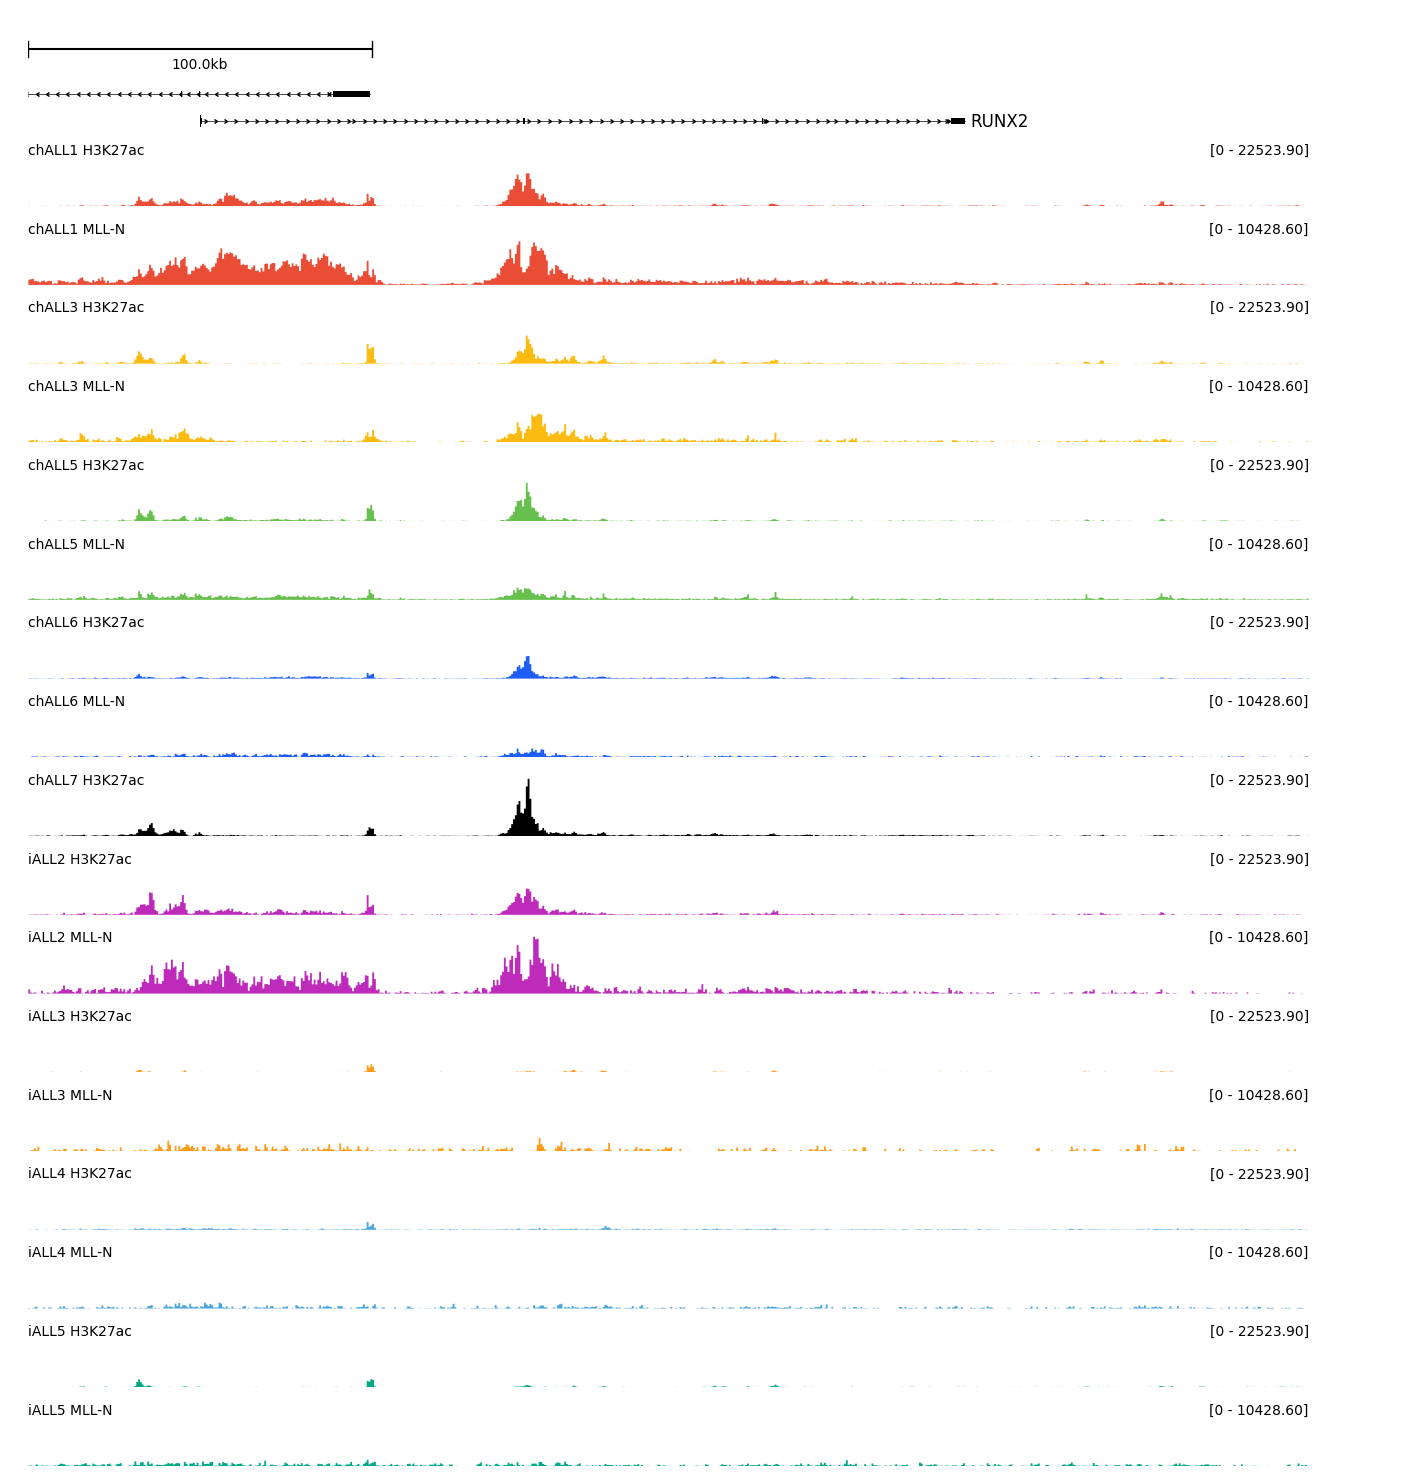

In [31]:
f = fig.plot_gene(
    "RUNX2", "hg38", extend={"upstream": 5e4, "downstream": 1e5}, height=0.5
)
f.savefig("novel_enhancers_main_figures/RUNX2.svg", bbox_inches="tight", dpi=300)
f

## With MCC

In [40]:
df_tracks_to_plot = pd.concat(
    [chip_tracks.query("patient_name == 'chALL1'"), df_archive]
)
df_tracks_to_plot["antibody"] = (
    df_tracks_to_plot.antibody.str.replace("H3K27AC", "H3K27ac")
    .replace("MLLN", "MLL-N")
    .replace("AF4C", "AF4-C")
)
df_tracks_to_plot["patient_name"] = df_tracks_to_plot.patient_name.fillna("SEM")
df_tracks_to_plot["antibody"] = pd.Categorical(
    df_tracks_to_plot.antibody, categories=["H3K27ac", "MLL-N", "AF4-C"], ordered=True
)
df_tracks_to_plot = df_tracks_to_plot.sort_values(["patient_name", "antibody"])
df_tracks_to_plot

,path,name,assay,patient,is_xeno,antibody,patient_name
36,/ceph/project/milne_group/shared/seqnado_archi...,sem-h3k27ac_h3k27ac,NaN,NaN,NaN,H3K27ac,SEM
34,/ceph/project/milne_group/shared/seqnado_archi...,sem-mlln_mlln,NaN,NaN,NaN,MLL-N,SEM
40,/ceph/project/milne_group/shared/seqnado_archi...,sem-af4c_af4c,NaN,NaN,NaN,AF4-C,SEM
102,/home/a/asmith/project_milne_group/Projects/20...,chALL-26754-CM_H3K27ac,CM,26754,False,H3K27ac,chALL1
35,/home/a/asmith/project_milne_group/Projects/20...,chALL-26754-CM_MLLN,CM,26754,False,MLL-N,chALL1


In [36]:
fig = Figure(autospacing=True, highlight_regions=highlight)


# Standard tracks
fig.add_track("scale")
fig.add_track(
    "genes", genome="hg38", gene_style="normal", min_gene_length=int(1.2e5), height=0.5
)

# MCC tracks
mcc_sem = TrackWrapper(
    "bigwig",
    get_mcc_track(mcc_tracks, viewpoint=VIEWPOINT, sample_name="SEM"),
    title="SEM MCC",
    color="black",
    style="stairsfilled",
    number_of_bins=1000,
    data_range_style="text",
    data_range_location="right",
    label_on_track=True,
    label_loc="left",
    max_value=5,
)
mcc_patient = TrackWrapper(
    "bigwig",
    get_mcc_track(mcc_tracks, viewpoint=VIEWPOINT, sample_name="chALL1"),
    title="chALL1 MCC",
    color=patient_sample_colors["chALL1"],
    style="stairsfilled",
    number_of_bins=1000,
    data_range_style="text",
    data_range_location="right",
    label_on_track=True,
    label_loc="left",
    max_value=5,
)

fig.add_track(mcc_sem)
fig.add_track(mcc_patient)

# ChIP tracks
for track in df_tracks_to_plot.itertuples():
    fig.add_track(
        "bigwig",
        file=str(track.path),
        style="stairsfilled",
        color=get_color(track.patient_name, patient_sample_colors),
        title=f"{track.patient_name} {track.antibody}",
        data_range_style="text",
        data_range_location="right",
        label_on_track=True,
        label_loc="left",
        autoscale_group=track.antibody,
    )


# Add genomic axis
fig.add_track("xaxis")

[W::hts_idx_load3] The index file is older than the data file: /ceph/project/milne_group/asmith/software/mambaforge/envs/plotnado/lib/python3.12/site-packages/plotnado/data/gene_bed_files/hg38_genes.bed.bgz.tbi
2024-09-03 14:23:18.474 | DEBUG    | plotnado.api.genes:plot_genes:176 - ylim 330.0,0


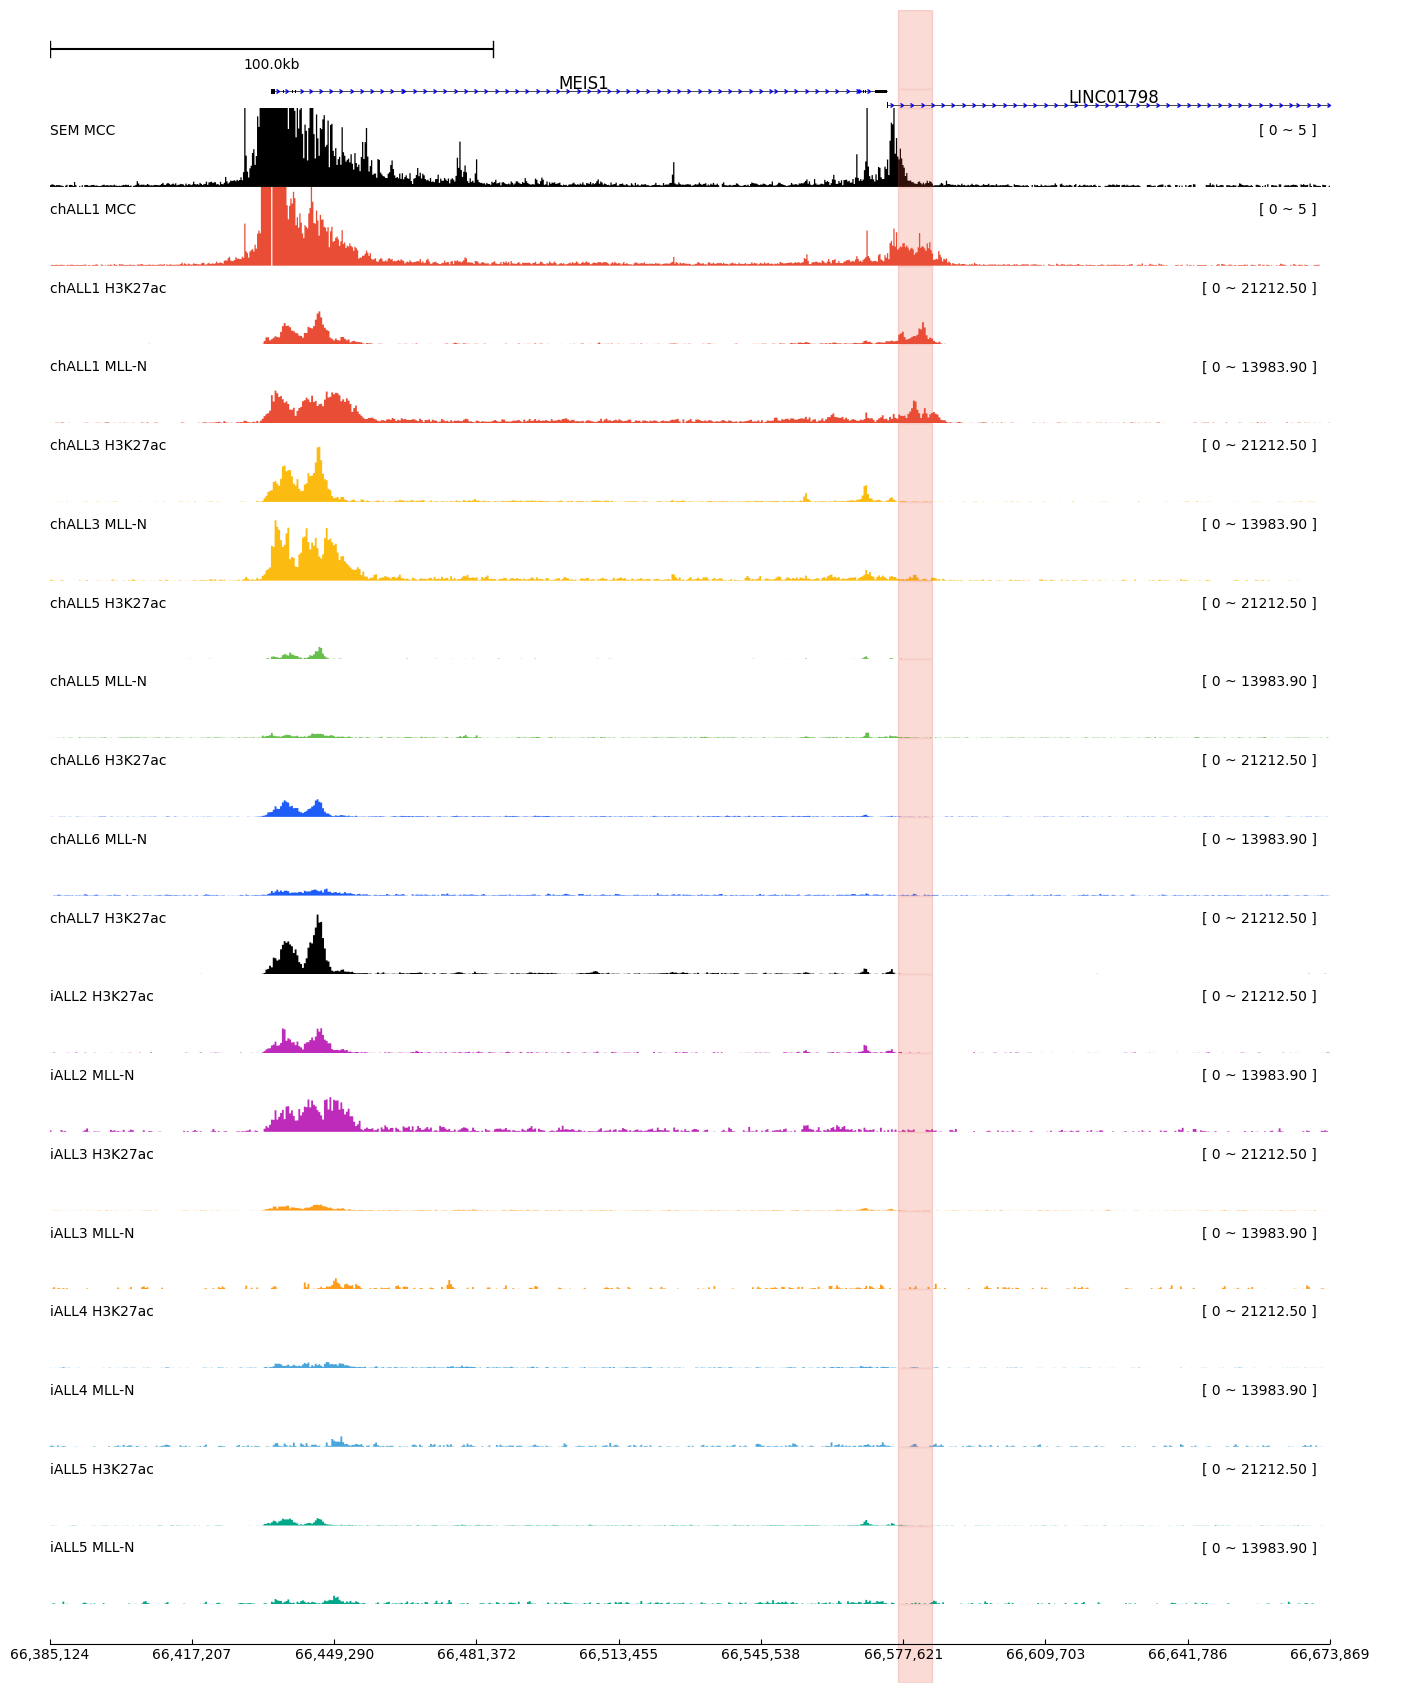

In [60]:
fig.plot_gene("MEIS1", "hg38", extend={"upstream": 5e4, "downstream": 1e5}, height=0.5)

# Repeat for other viewpoints of interest

In [54]:
def make_figure(
    viewpoint: str,
    chip_tracks: pd.DataFrame,
    mcc_tracks: pd.DataFrame,
    colors: Dict[str, str],
    highlight: Optional[cb.HighLights] = None,
    min_gene_length: int = int(1.2e5),
    mcc_max_value: int = 5,
) -> Figure:
    fig = Figure(autospacing=True, highlight_regions=highlight if highlight else None)

    # Standard tracks
    fig.add_track("scale")
    fig.add_track(
        "genes",
        genome="hg38",
        gene_style="normal",
        min_gene_length=min_gene_length,
        height=0.5,
        label_y_offset=-75,
        label_loc="right",
        arrow_color="black",
    )

    # MCC tracks
    sem_track = get_mcc_track(mcc_tracks, viewpoint=viewpoint, sample_name="SEM")
    patient_track = get_mcc_track(mcc_tracks, viewpoint=viewpoint, sample_name="chALL1")

    if sem_track:
        mcc_sem = TrackWrapper(
            "bigwig",
            sem_track,
            title="SEM MCC",
            color="black",
            style="stairsfilled",
            number_of_bins=1000,
            data_range_style="text",
            data_range_location="right",
            label_on_track=True,
            label_loc="left",
            max_value=mcc_max_value,
        )

        fig.add_track(mcc_sem)

    if patient_track:
        mcc_patient = TrackWrapper(
            "bigwig",
            get_mcc_track(mcc_tracks, viewpoint=viewpoint, sample_name="chALL1"),
            title="chALL1 MCC",
            color=colors["chALL1"],
            style="stairsfilled",
            number_of_bins=1000,
            data_range_style="text",
            data_range_location="right",
            label_on_track=True,
            label_loc="left",
            max_value=mcc_max_value,
        )
        fig.add_track(mcc_patient)

    # ChIP tracks
    for track in chip_tracks.itertuples():
        fig.add_track(
            "bigwig",
            file=str(track.path),
            style="stairsfilled",
            color=get_color(track.patient_name, colors),
            title=f"{track.patient_name} {track.antibody}",
            data_range_style="text",
            data_range_location="right",
            label_on_track=True,
            label_loc="left",
            autoscale_group=track.antibody,
        )

    # Add genomic axis
    fig.add_track("xaxis")

    return fig

In [55]:
!mkdir -p mcc_figures

## MEIS1

[W::hts_idx_load3] The index file is older than the data file: /ceph/project/milne_group/asmith/Projects/plotnado/plotnado/data/gene_bed_files/hg38_genes.bed.bgz.tbi
2024-09-04 19:09:40.326 | DEBUG    | plotnado.api.genes:__get_length_w:49 - len of w set to: 2517.278123702781 bp
2024-09-04 19:09:40.347 | DEBUG    | plotnado.api.genes:plot_genes:206 - ylim 330.0,0


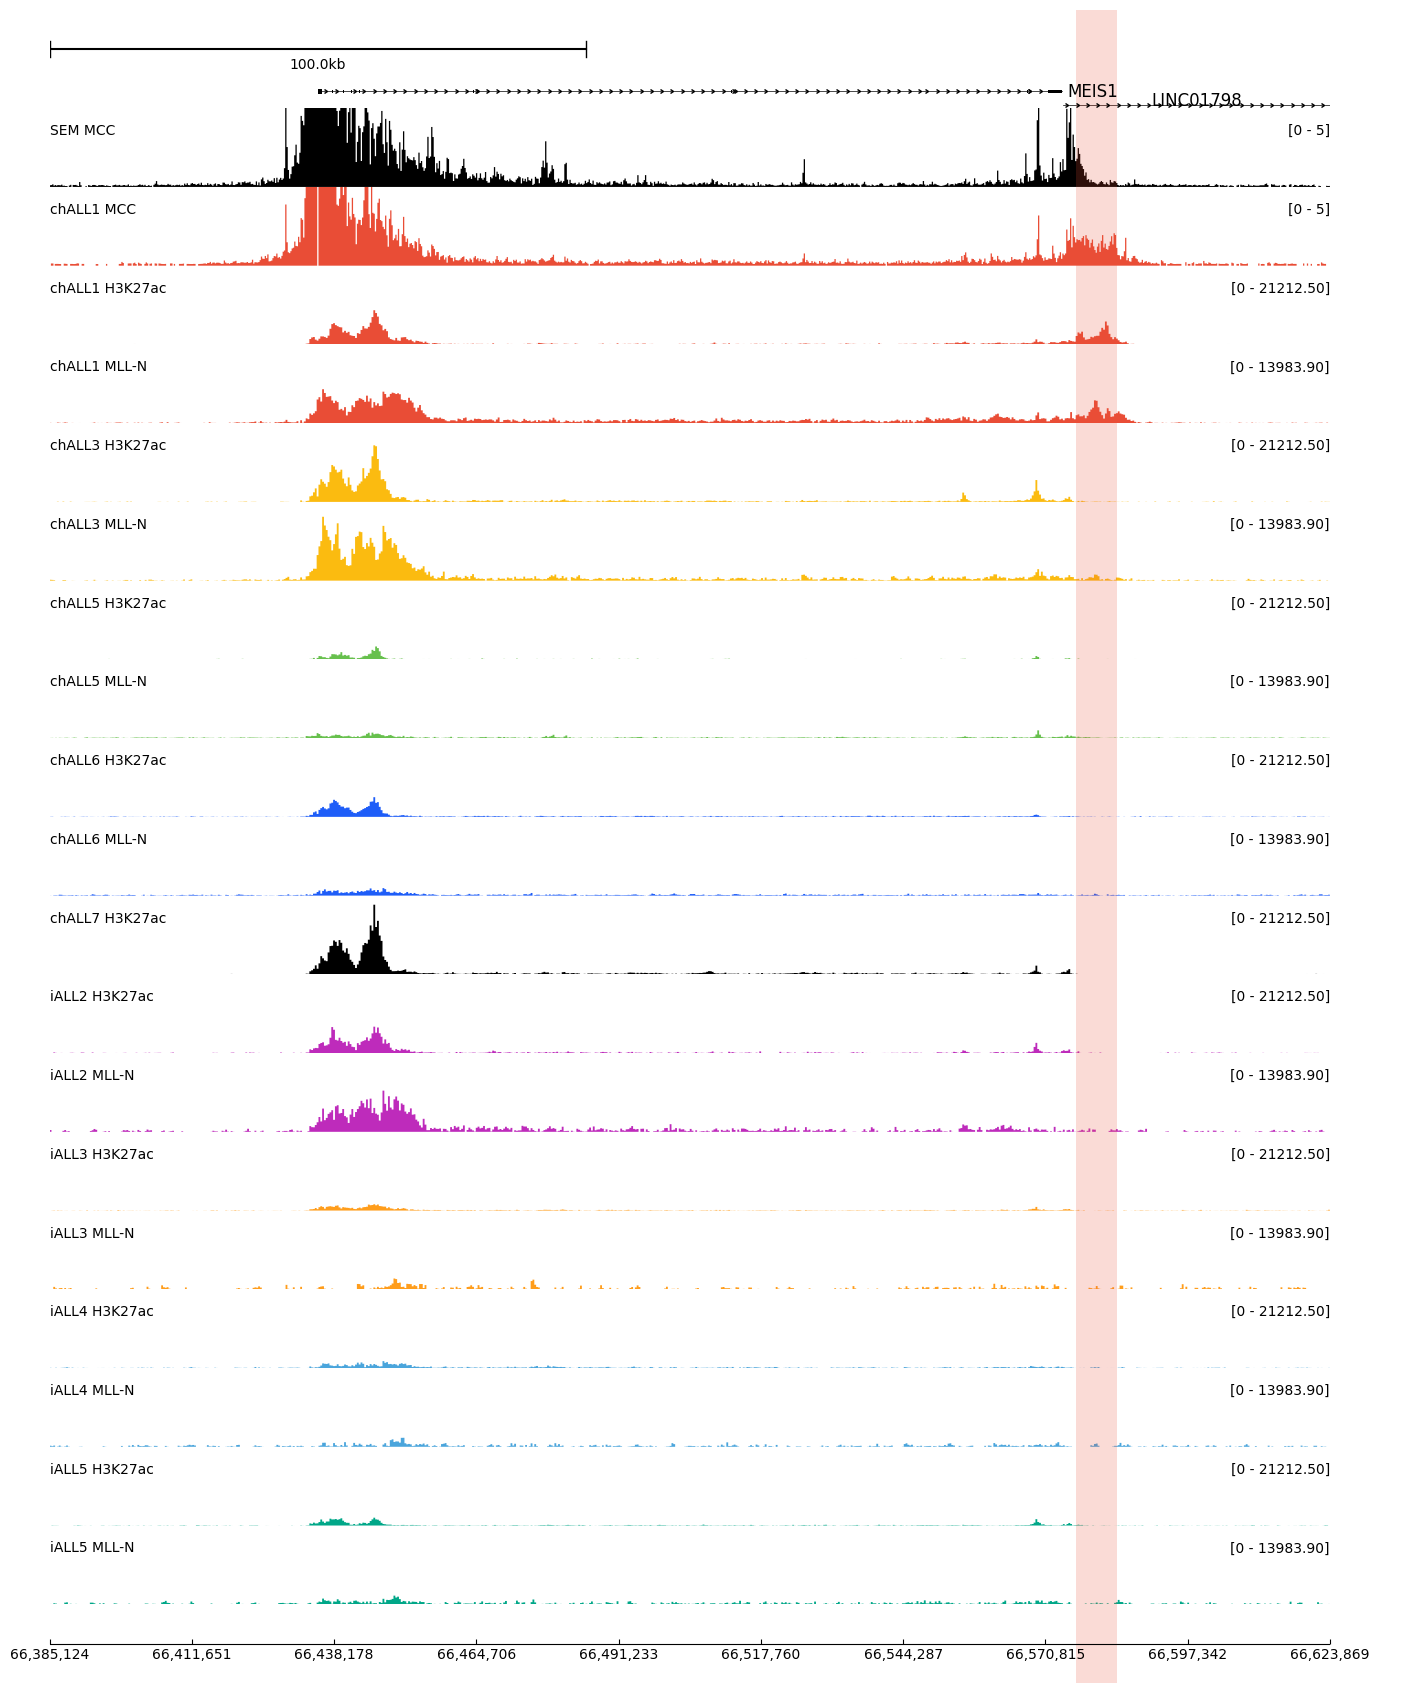

In [56]:
fig = make_figure("MEIS1", chip_tracks, mcc_tracks, patient_sample_colors, highlight)
f = fig.plot_gene("MEIS1", "hg38", extend=int(5e4))
f.savefig("mcc_figures/MEIS1.svg", bbox_inches="tight")
f

## RUNX2

[ERROR:base.py:264 -       plot_coverages()] Error occured when plot track's coverage:
	track name: ScaleBar.15
	track type:<class 'plotnado.api.tracks.ScaleBar'>
	coverage name: HighlightsFromFile.2
	cov type: <class 'plotnado.api.tracks.HighlightsFromFile'>
	Error: <class 'KeyError'> '6'
[ERROR:base.py:269 -       plot_coverages()] '6'
Traceback (most recent call last):
  File "/ceph/project/milne_group/asmith/software/mambaforge/envs/ma4_th/lib/python3.10/site-packages/coolbox/core/track/base.py", line 262, in plot_coverages
    cov.plot(ax, copy(gr), gr2=copy(gr2))
  File "/ceph/project/milne_group/asmith/Projects/plotnado/plotnado/api/tracks.py", line 1370, in plot
    regions = self.fetch_data(gr, **kwargs)
  File "/ceph/project/milne_group/asmith/software/mambaforge/envs/ma4_th/lib/python3.10/site-packages/coolbox/core/coverage/highlights.py", line 24, in fetch_data
    self.interval_tree[gr.chrom][gr.start - 10000 : gr.end + 10000]
KeyError: '6'
[W::hts_idx_load3] The index fil

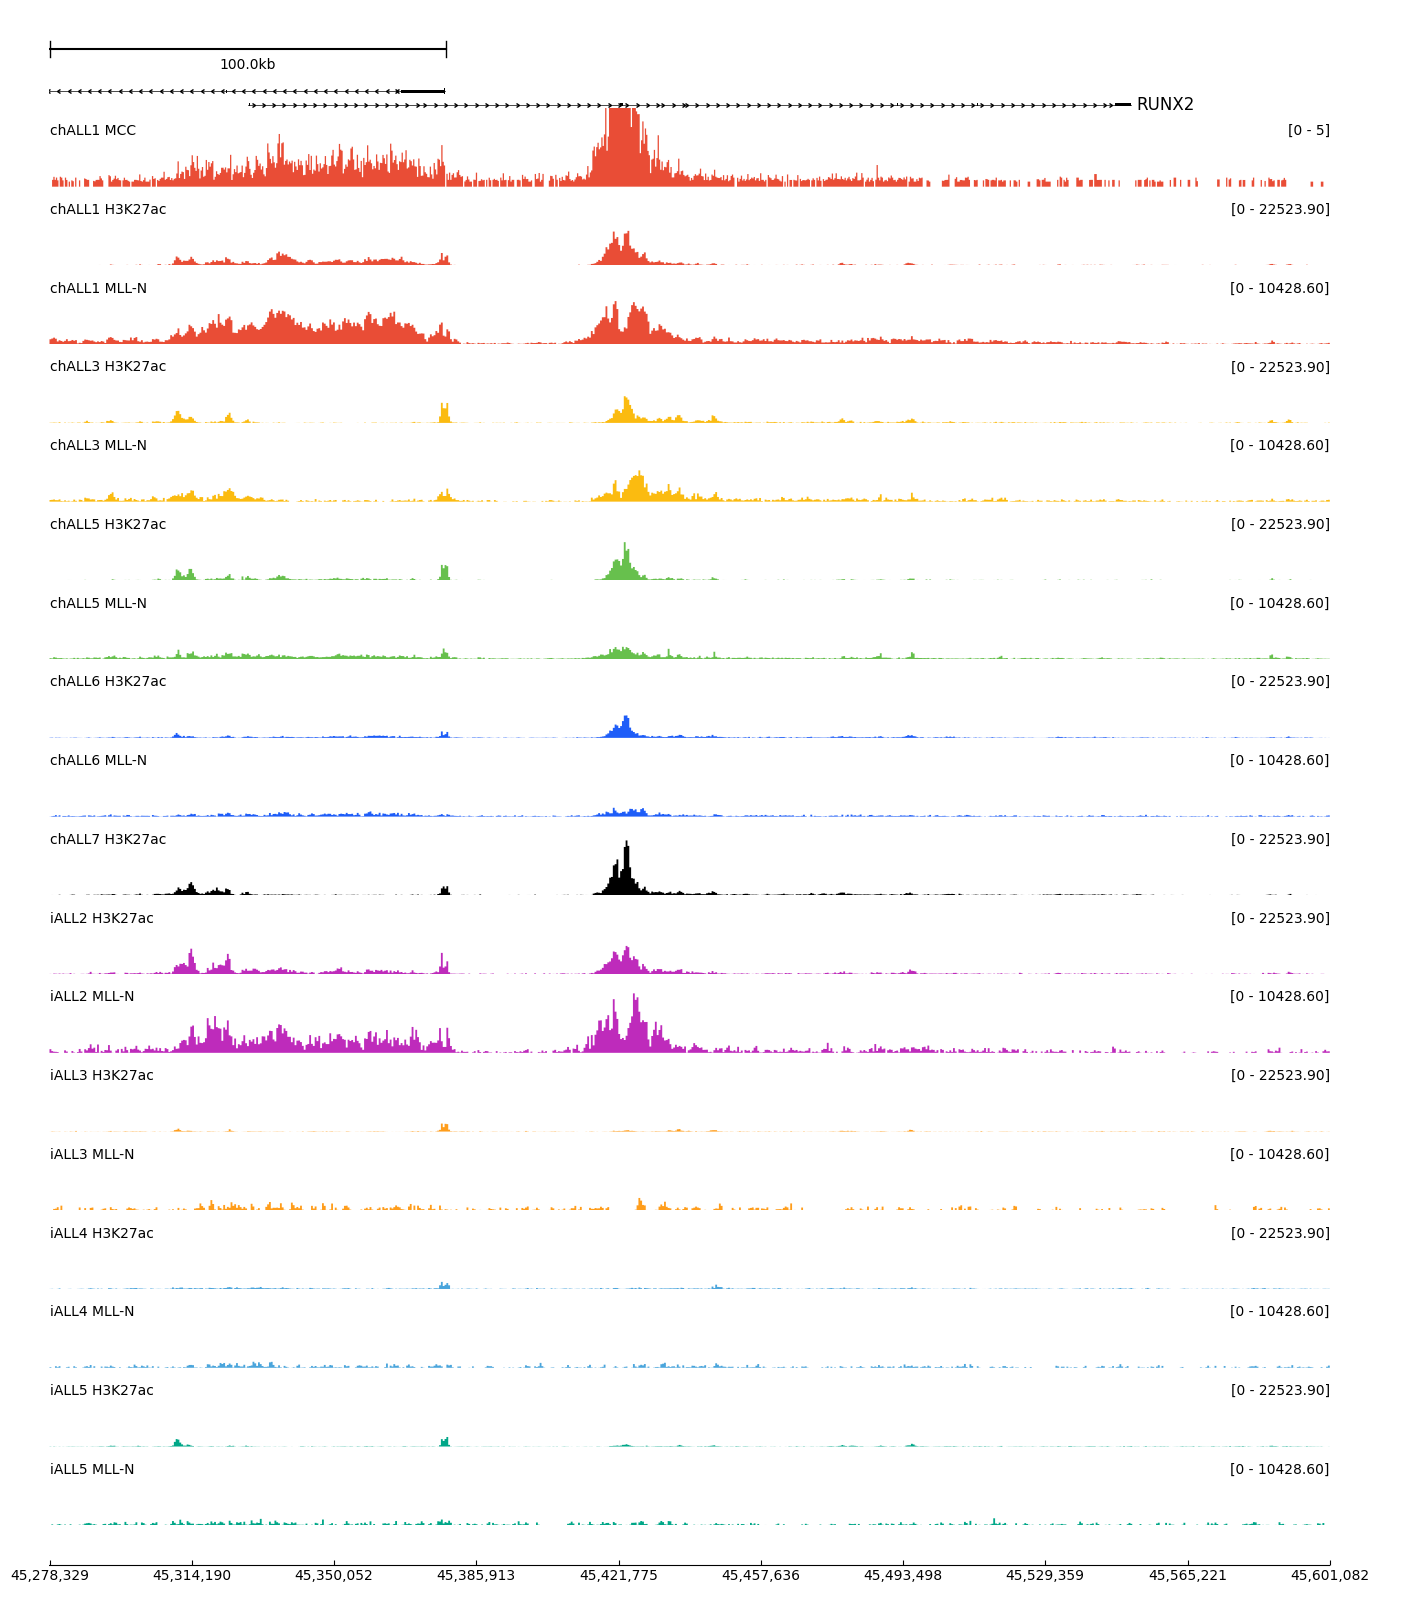

In [57]:
fig = make_figure("RUNX2", chip_tracks, mcc_tracks, patient_sample_colors, highlight)
f = fig.plot_gene("RUNX2", "hg38", extend=int(5e4))
f.savefig("mcc_figures/RUNX2.svg", bbox_inches="tight")
f

## CD69

[W::hts_idx_load3] The index file is older than the data file: /ceph/project/milne_group/asmith/Projects/plotnado/plotnado/data/gene_bed_files/hg38_genes.bed.bgz.tbi
2024-09-04 19:09:57.443 | DEBUG    | plotnado.api.genes:__get_length_w:49 - len of w set to: 2197.495392278954 bp
2024-09-04 19:09:57.546 | DEBUG    | plotnado.api.genes:plot_genes:206 - ylim 789.9999999999999,0


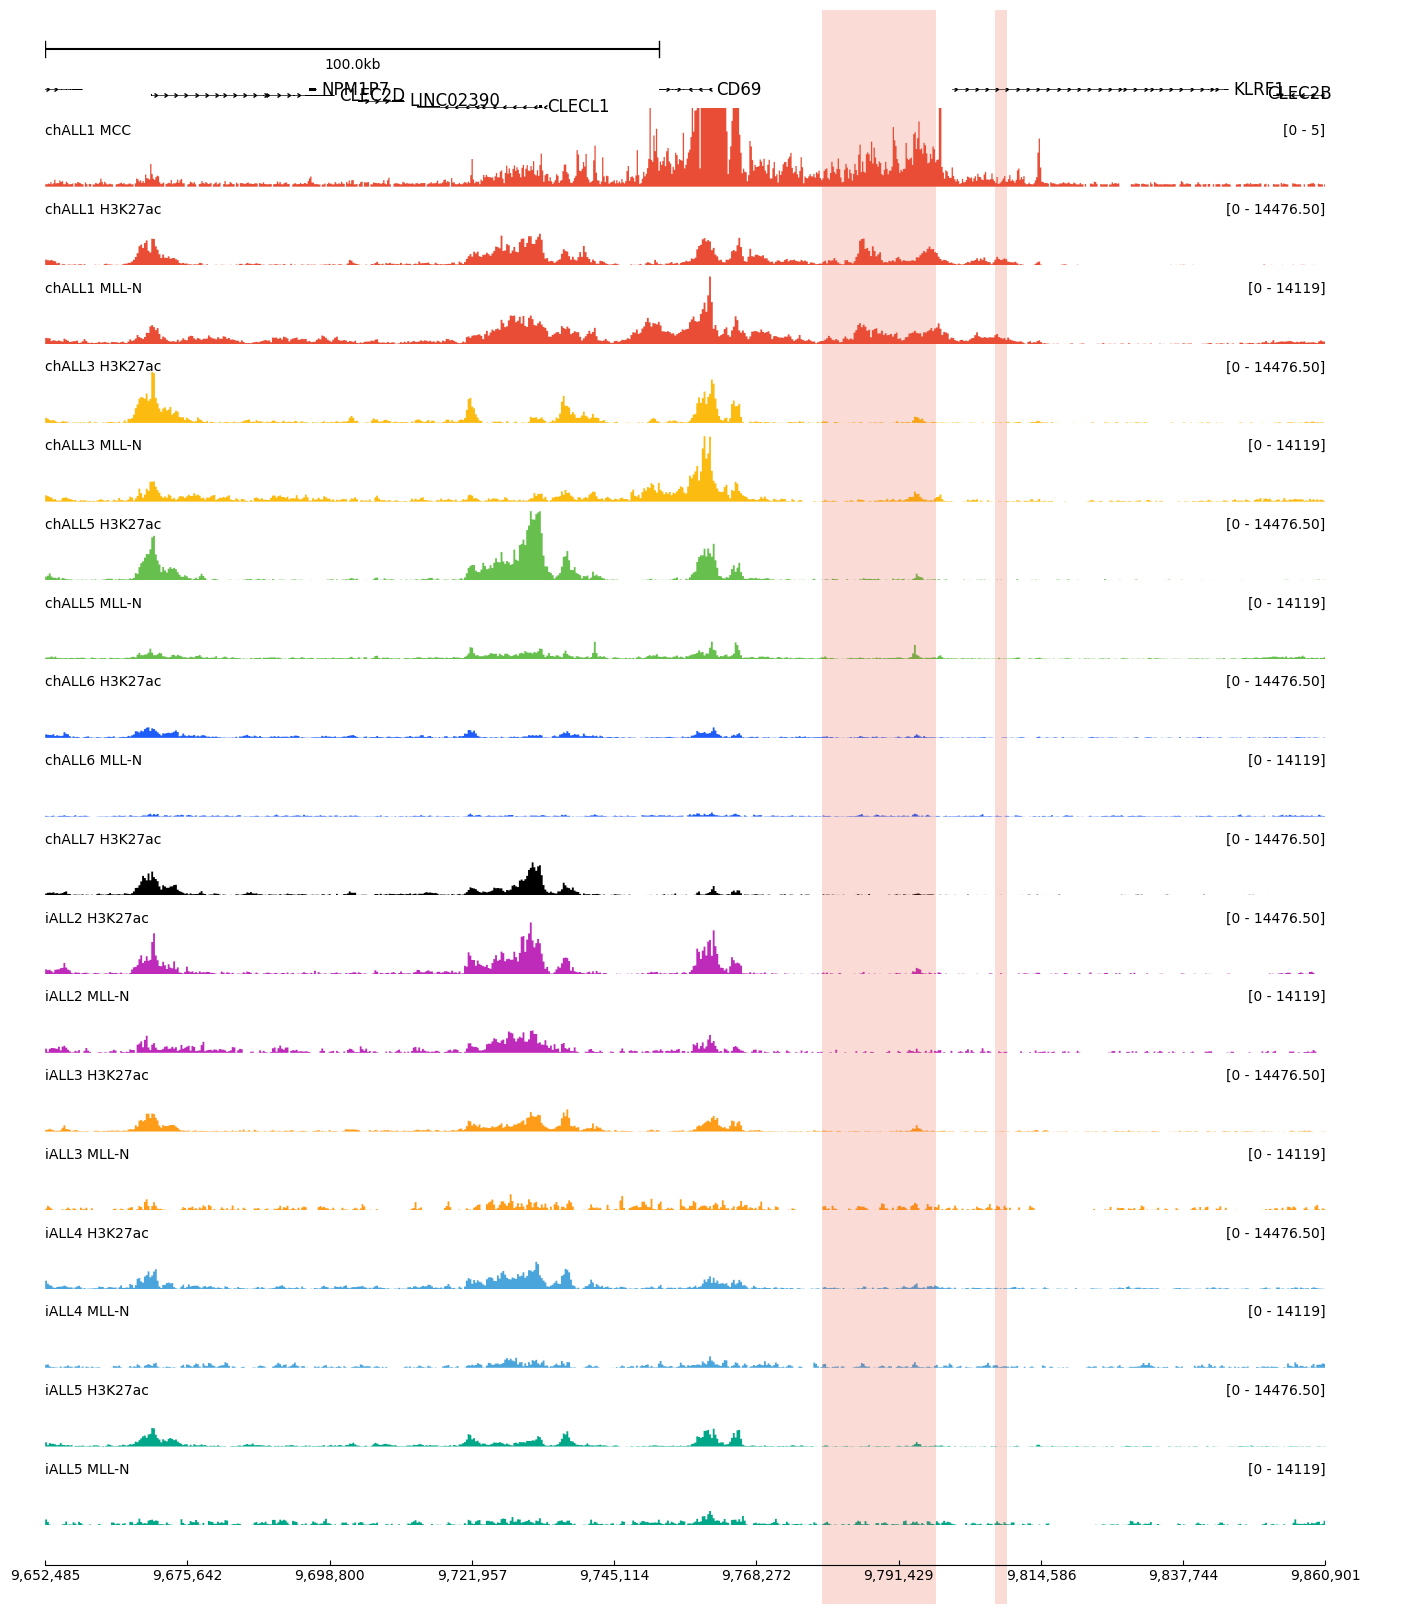

In [58]:
fig = make_figure(
    "CD69",
    chip_tracks,
    mcc_tracks,
    patient_sample_colors,
    highlight,
    min_gene_length=int(1e3),
)
f = fig.plot_gene("CD69", "hg38", extend=int(1e5))
f.savefig("mcc_figures/CD69.svg", bbox_inches="tight")
f

## ARID1B

[ERROR:base.py:264 -       plot_coverages()] Error occured when plot track's coverage:
	track name: ScaleBar.17
	track type:<class 'plotnado.api.tracks.ScaleBar'>
	coverage name: HighlightsFromFile.2
	cov type: <class 'plotnado.api.tracks.HighlightsFromFile'>
	Error: <class 'KeyError'> '6'
[ERROR:base.py:269 -       plot_coverages()] '6'
Traceback (most recent call last):
  File "/ceph/project/milne_group/asmith/software/mambaforge/envs/ma4_th/lib/python3.10/site-packages/coolbox/core/track/base.py", line 262, in plot_coverages
    cov.plot(ax, copy(gr), gr2=copy(gr2))
  File "/ceph/project/milne_group/asmith/Projects/plotnado/plotnado/api/tracks.py", line 1370, in plot
    regions = self.fetch_data(gr, **kwargs)
  File "/ceph/project/milne_group/asmith/software/mambaforge/envs/ma4_th/lib/python3.10/site-packages/coolbox/core/coverage/highlights.py", line 24, in fetch_data
    self.interval_tree[gr.chrom][gr.start - 10000 : gr.end + 10000]
KeyError: '6'
[W::hts_idx_load3] The index fil

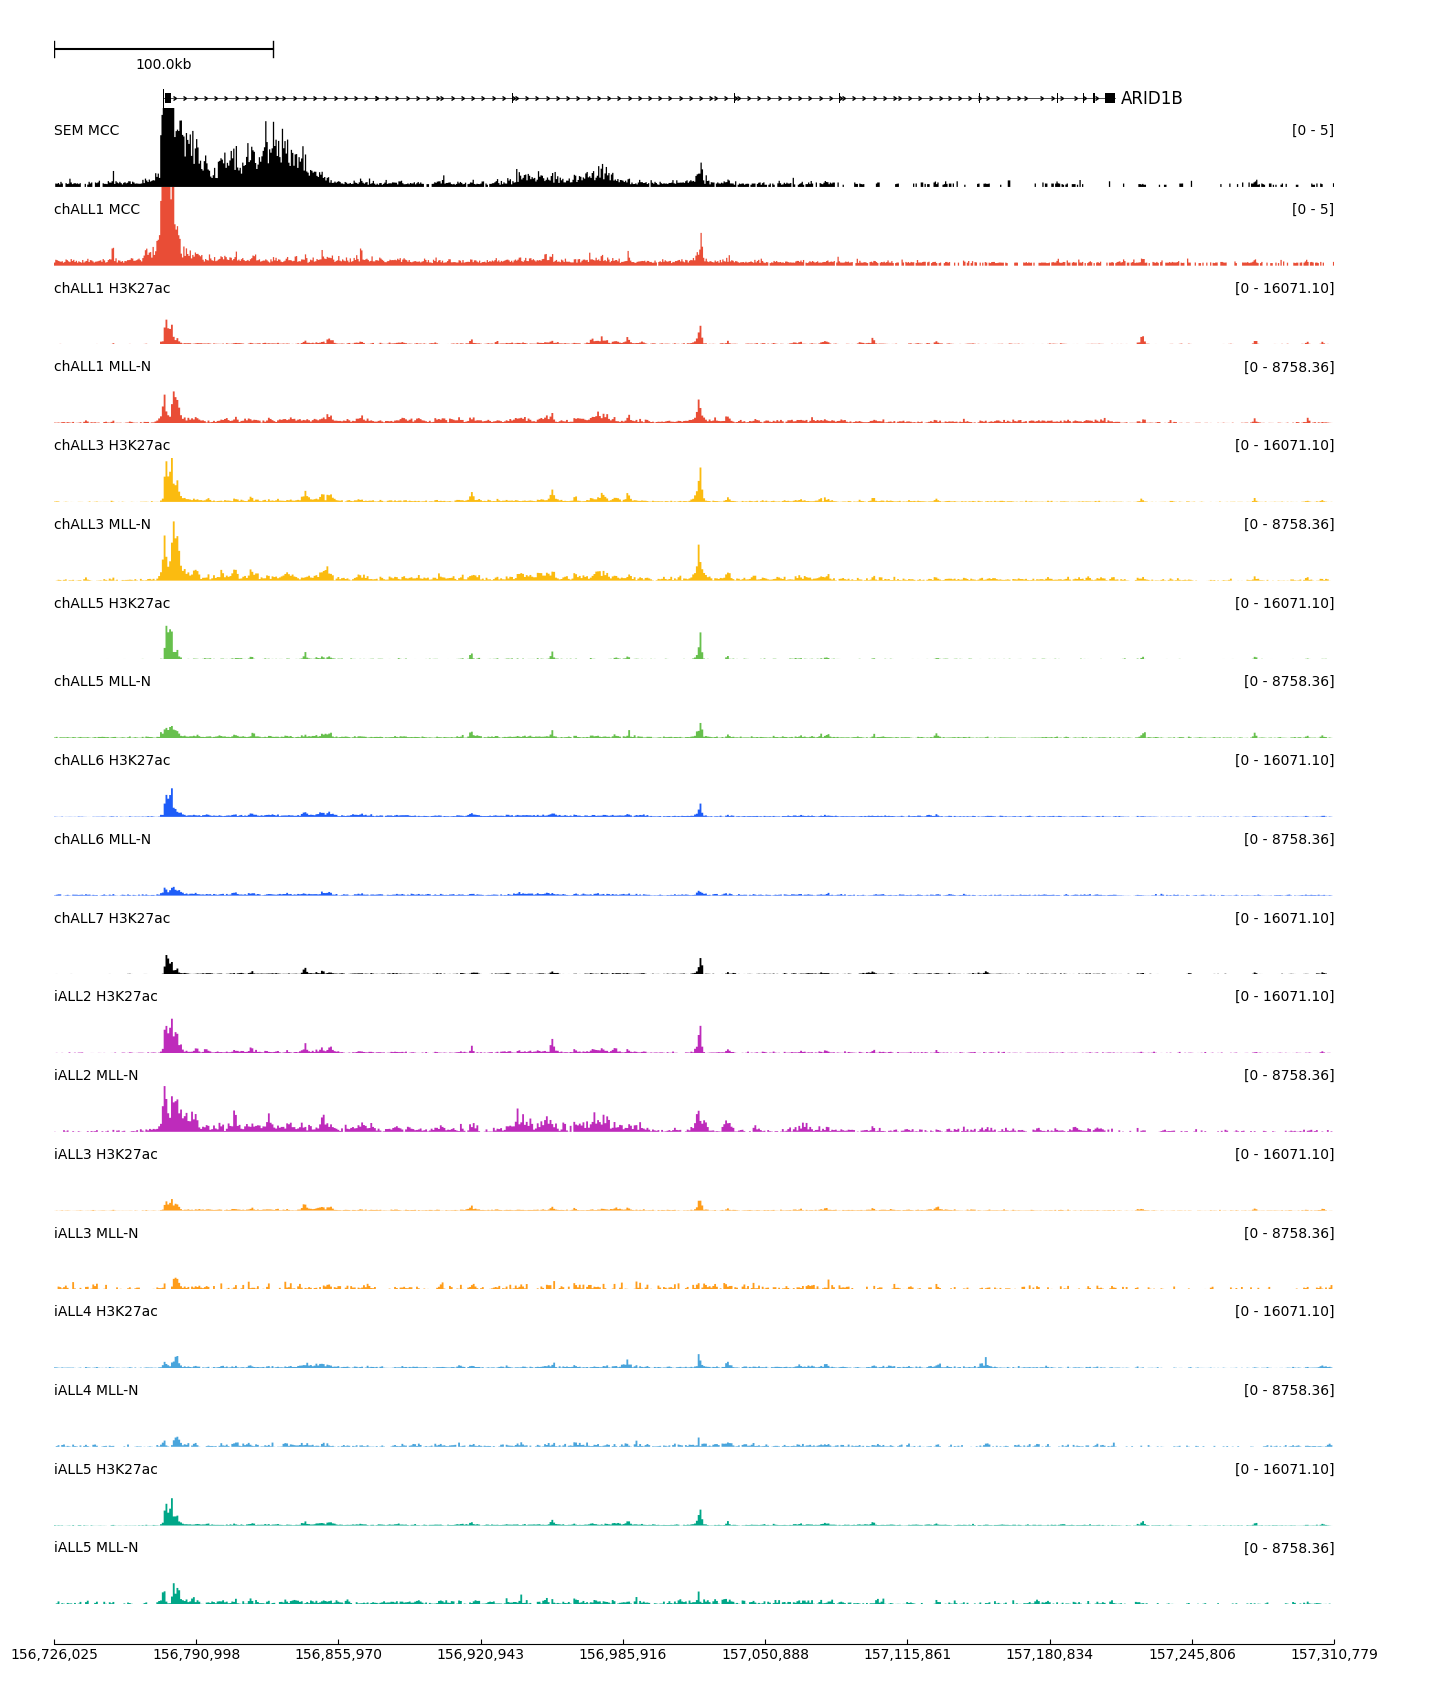

In [59]:
fig = make_figure("ARID1B", chip_tracks, mcc_tracks, patient_sample_colors, highlight)
f = fig.plot_gene(
    "ARID1B", "hg38", extend={"upstream": 5e4, "downstream": 1e5}, height=0.5
)
f.savefig("mcc_figures/ARID1B.svg", bbox_inches="tight")
f

## GNAQ -- BAD capture

In [65]:
# fig = make_figure('GNAQ', chip_tracks, mcc_tracks, patient_sample_colors, highlight, mcc_max_value=10)
# fig.plot_gene('GNAQ', 'hg38', extend=int(1e5))

## IGLL1

[ERROR:base.py:264 -       plot_coverages()] Error occured when plot track's coverage:
	track name: ScaleBar.18
	track type:<class 'plotnado.api.tracks.ScaleBar'>
	coverage name: HighlightsFromFile.2
	cov type: <class 'plotnado.api.tracks.HighlightsFromFile'>
	Error: <class 'KeyError'> '22'
[ERROR:base.py:269 -       plot_coverages()] '22'
Traceback (most recent call last):
  File "/ceph/project/milne_group/asmith/software/mambaforge/envs/ma4_th/lib/python3.10/site-packages/coolbox/core/track/base.py", line 262, in plot_coverages
    cov.plot(ax, copy(gr), gr2=copy(gr2))
  File "/ceph/project/milne_group/asmith/Projects/plotnado/plotnado/api/tracks.py", line 1370, in plot
    regions = self.fetch_data(gr, **kwargs)
  File "/ceph/project/milne_group/asmith/software/mambaforge/envs/ma4_th/lib/python3.10/site-packages/coolbox/core/coverage/highlights.py", line 24, in fetch_data
    self.interval_tree[gr.chrom][gr.start - 10000 : gr.end + 10000]
KeyError: '22'
[W::hts_idx_load3] The index 

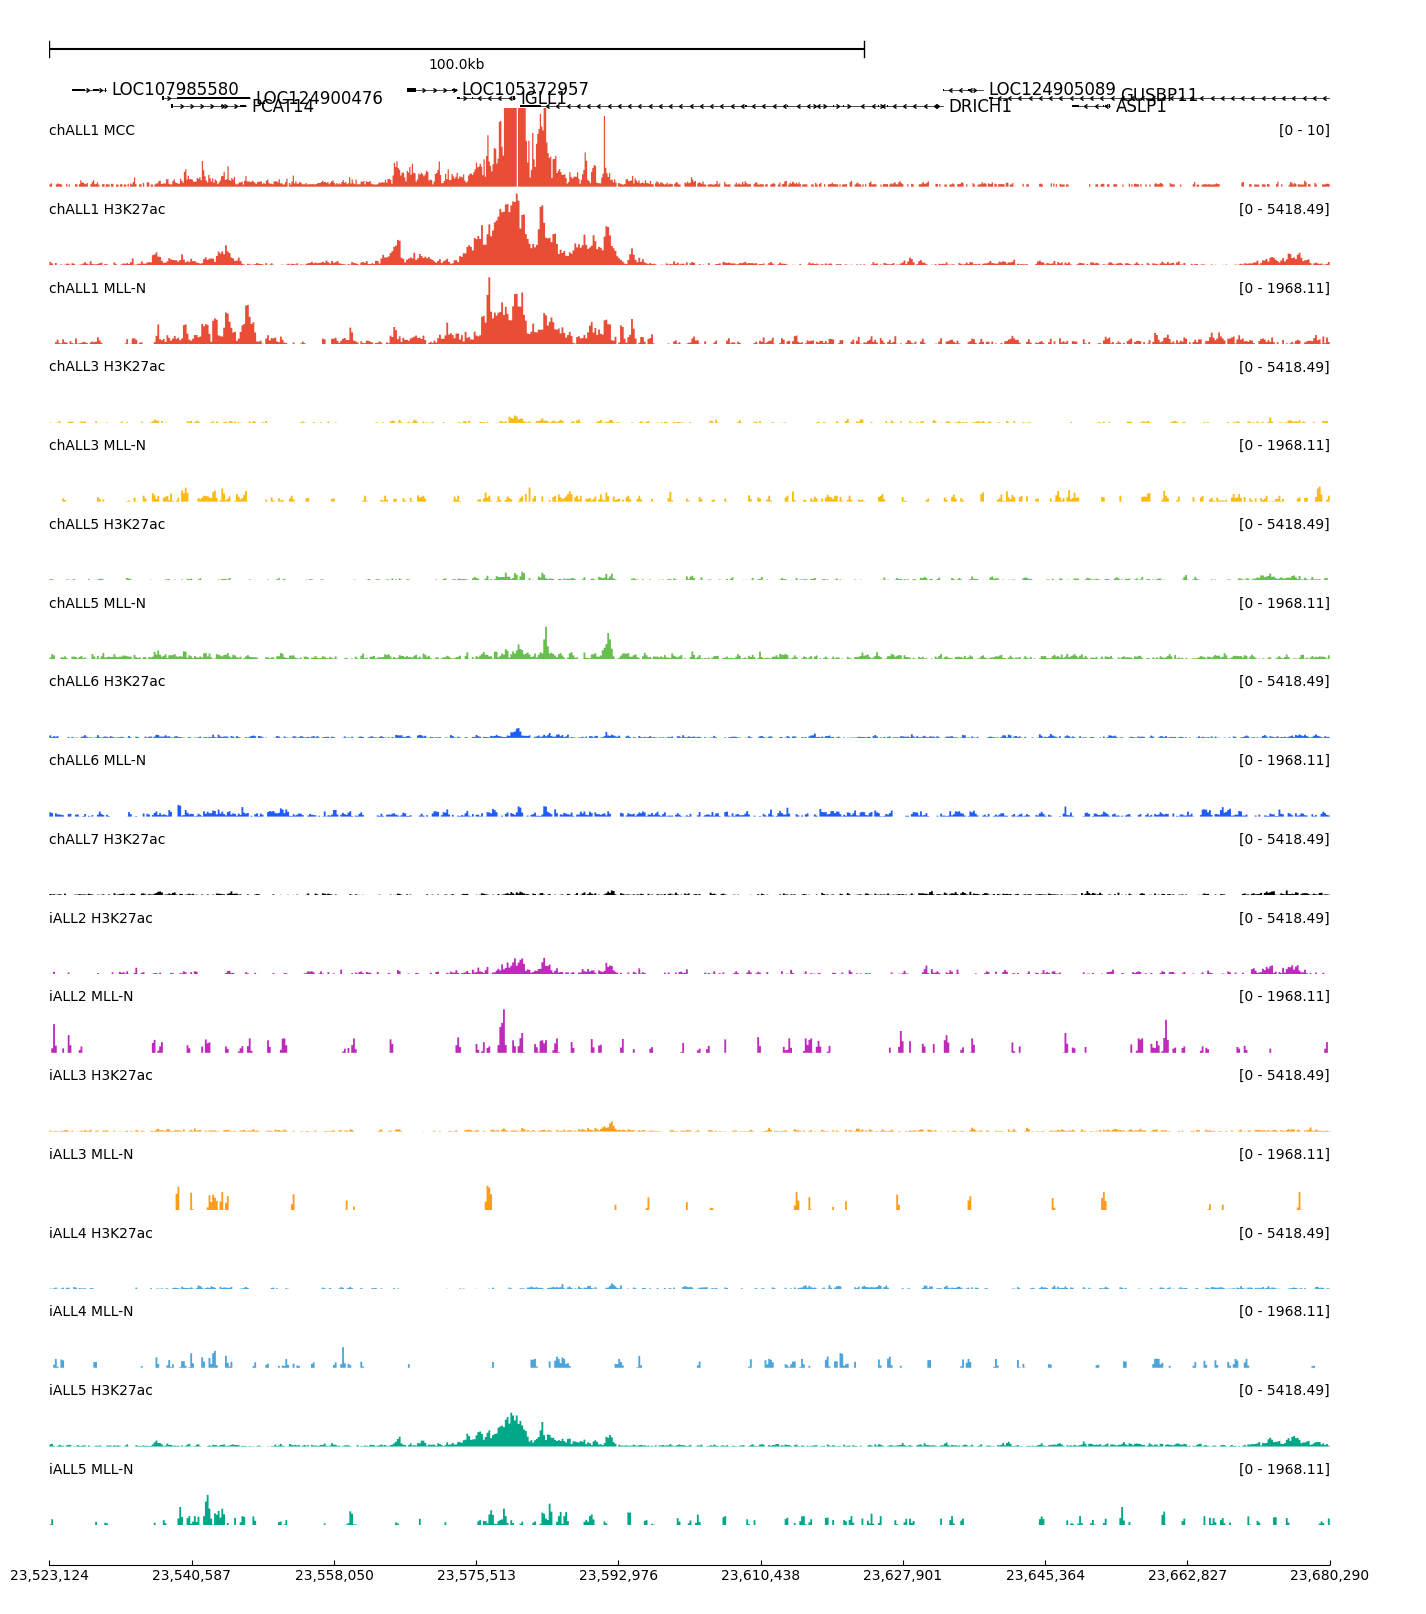

In [60]:
fig = make_figure(
    "IGLL1",
    chip_tracks,
    mcc_tracks,
    patient_sample_colors,
    highlight=highlight,
    min_gene_length=int(1e3),
    mcc_max_value=10,
)
f = fig.plot_gene(
    "IGLL1",
    "hg38",
    extend={"upstream": 5e4, "downstream": 1e5},
)
f.savefig("mcc_figures/IGLL1.svg", bbox_inches="tight")
f

## FLT3

In [61]:
fig = make_figure(
    "FLT3",
    chip_tracks,
    mcc_tracks,
    patient_sample_colors,
    highlight=highlight,
    min_gene_length=int(5e4),
    mcc_max_value=5,
)
f = fig.plot_gene(
    "FLT3",
    "hg38",
    extend={"upstream": 5e4, "downstream": 2e5},
)
f.savefig("mcc_figures/FLT3.svg", bbox_inches="tight")

[ERROR:base.py:264 -       plot_coverages()] Error occured when plot track's coverage:
	track name: ScaleBar.19
	track type:<class 'plotnado.api.tracks.ScaleBar'>
	coverage name: HighlightsFromFile.2
	cov type: <class 'plotnado.api.tracks.HighlightsFromFile'>
	Error: <class 'KeyError'> '13'
[ERROR:base.py:269 -       plot_coverages()] '13'
Traceback (most recent call last):
  File "/ceph/project/milne_group/asmith/software/mambaforge/envs/ma4_th/lib/python3.10/site-packages/coolbox/core/track/base.py", line 262, in plot_coverages
    cov.plot(ax, copy(gr), gr2=copy(gr2))
  File "/ceph/project/milne_group/asmith/Projects/plotnado/plotnado/api/tracks.py", line 1370, in plot
    regions = self.fetch_data(gr, **kwargs)
  File "/ceph/project/milne_group/asmith/software/mambaforge/envs/ma4_th/lib/python3.10/site-packages/coolbox/core/coverage/highlights.py", line 24, in fetch_data
    self.interval_tree[gr.chrom][gr.start - 10000 : gr.end + 10000]
KeyError: '13'
[W::hts_idx_load3] The index 

## Read the hub to determine which viewpoints are present

In [50]:
def find_track_in_hub(url, genome="hg38"):
    """
    Find the track in the hub file

    Parameters
    ----------
    url : str
        The URL to the hub file
        e.g. 'https://datashare.molbiol.ox.ac.uk/public/project/davieslab/ndenny/02_MCC/leukaemic_cell_line_cap_hg38/leukaemic_cell_line_cap_hg38_ext_de_norm_rep_hub.txt'
    """

    trackdb = pathlib.Path(url).parent / genome / "trackDb.txt"
    trackdb = str(trackdb).replace(":/", "://")
    df = pd.read_table(trackdb, header=None)
    df = df[0].str.split(" ", expand=True).rename(columns={0: "attribute", 1: "value"})
    df["group"] = (df["attribute"] == "track").cumsum()
    df["track"] = df.groupby("group")["value"].transform(
        lambda x: x.iloc[0].split("_")[0]
    )
    return df

In [51]:
hub_address_patient = "https://datashare.molbiol.ox.ac.uk/public/project/Wellcome_Discovery/ndenny/04_mllaf4_enhancers/26954_idt_panel/hub.txt"
hub_address_sem = "https://datashare.molbiol.ox.ac.uk/public/project/davieslab/ndenny/02_MCC/leukaemic_cell_line_cap_hg38/leukaemic_cell_line_cap_hg38_ext_de_norm_rep_hub.txt"
# trackdb = "https://datashare.molbiol.ox.ac.uk/public/project/Wellcome_Discovery/ndenny/04_mllaf4_enhancers/26954_idt_panel/hg38/trackDb.txt"
trackdb_sem = "https://datashare.molbiol.ox.ac.uk/public/project/davieslab/ndenny/02_MCC/leukaemic_cell_line_cap_hg38/leukaemic_cell_line_cap_hg38_ext_de_norm_rep_tracks.txt"

### Patient data

In [52]:
df_tracks_patient = find_track_in_hub(hub_address_patient)
df_tracks_patient = df_tracks_patient.query('track != "26954"')

### Cell line data

In [53]:
def get_cell_line(x):
    if "SEM" in x:
        return "SEM"
    elif "THP1" in x:
        return "THP1"

In [54]:
import requests
import re

with requests.get(trackdb_sem) as r:
    lines = r.text.split("\n")

lines = [l.split(" ") for l in lines if not l.startswith("#") and not l == ""]
df = (
    pd.DataFrame(lines)
    .rename(columns={0: "attribute", 1: "value"})
    .drop(columns=[2, 3])
)
df["group"] = (df["attribute"] == "track").cumsum()
df["track"] = df.groupby("group")["value"].transform(lambda x: x.iloc[0].split("_")[0])
df["cell_line"] = df.groupby("group")["value"].transform(
    lambda x: get_cell_line(x.iloc[0])
)
df = df.query('track != "SEM" and track != "THP1" and cell_line == "SEM"')


df_tracks_sem = df
df_tracks_sem

,attribute,value,group,track,cell_line
158,track,ABCA2_ext_de_norm_rep_SEM_fifty_oligo_cap_hg38...,9,ABCA2,SEM
159,type,bigWig,9,ABCA2,SEM
160,longLabel,,9,ABCA2,SEM
161,shortLabel,ABCA2_ext_de_norm_rep_SEM_fifty_oligo_cap_hg38...,9,ABCA2,SEM
162,bigDataUrl,https://datashare.molbiol.ox.ac.uk/public/proj...,9,ABCA2,SEM
...,...,...,...,...,...
1469,longLabel,,144,ZNRF1,SEM
1470,shortLabel,ZNRF1_ext_de_norm_rep_SEM_fifty_oligo_cap_hg38...,144,ZNRF1,SEM
1471,parent,SEM_fifty_oligo_cap_hg38_ext_de_norm_rep_overlay,144,ZNRF1,SEM
1472,bigDataUrl,https://datashare.molbiol.ox.ac.uk/public/proj...,144,ZNRF1,SEM


## Identify matching genes

In [55]:
patient_genes = set(df_tracks_patient.track.unique())
sem_genes = set(df_tracks_sem.track.unique())

### 

In [56]:
genes_shared = patient_genes & sem_genes

In [57]:
genes_shared

{'ARID1B',
 'ASXL1',
 'BCL2',
 'CDK6',
 'EZH2',
 'FLT3',
 'FOS',
 'GNAQ',
 'IKZF1',
 'JMJD1C',
 'MBNL1',
 'MEF2C',
 'MEF2D',
 'MEIS1',
 'MYC',
 'PAX5',
 'PROM1',
 'TAPT1'}

In [58]:
genes_unique_patient = patient_genes - sem_genes
genes_unique_patient

{'AFF1',
 'ANKFY1',
 'ANO6',
 'ANTXR2',
 'ARID2',
 'BAZ2B',
 'BMI1',
 'CD69',
 'CDC40',
 'CDK12',
 'CHST3',
 'CLEC2B',
 'COMMD3',
 'CPEB2',
 'CSPG4',
 'CYB5D2',
 'DEFA5',
 'EBF1',
 'ELF1',
 'FAM53B',
 'FOXP1',
 'GAK',
 'HOXA10',
 'HOXA3',
 'HOXA7',
 'HOXA9',
 'HRK',
 'HSPBAP1',
 'IGLL1',
 'INPP5A',
 'IRF2',
 'IRX1',
 'JMY',
 'KAT6B',
 'KIF24',
 'KLRF1',
 'KMT2C',
 'LHPP',
 'MME',
 'MRPS23',
 'NCOA2',
 'PARP15',
 'PCDH9',
 'PDLIM1',
 'PRDM8',
 'RDX',
 'RTN4IP1',
 'RUNX2',
 'SMAD2',
 'SMAD7',
 'SMYD2',
 'SMYD3',
 'SPOCK2',
 'SPRING1',
 'SUPT3H',
 'TPGS2',
 'UBAP1',
 'ZC3H12C',
 'ZEB2'}

# Process the shared genes first using the same figure template

In [59]:
import requests

for gene in genes_shared:
    for source, df in zip(["chALL26754", "SEM"], [df_tracks_patient, df_tracks_sem]):
        url = df.query('track == @gene and attribute == "bigDataUrl"')["value"].values[
            0
        ]
        response = requests.get(url)

        with open(f"bigwigs_for_plotting/{source}_{gene}.bw", "wb") as f:
            f.write(response.content)

In [60]:
bws = pathlib.Path("bigwigs_for_plotting").glob("*.bw")
df_bw = pd.DataFrame(bws, columns=["path"])
df_bw["source"] = df_bw["path"].apply(lambda x: x.stem.split("_")[0])
df_bw["gene"] = df_bw["path"].apply(lambda x: x.stem.split("_")[1])
df_bw

,path,source,gene
0,bigwigs_for_plotting/chALL26754_JMY.bw,chALL26754,JMY
1,bigwigs_for_plotting/chALL26754_MRPS23.bw,chALL26754,MRPS23
2,bigwigs_for_plotting/chALL26754_HRK.bw,chALL26754,HRK
3,bigwigs_for_plotting/SEM_FOS.bw,SEM,FOS
4,bigwigs_for_plotting/chALL26754_IGLL1.bw,chALL26754,IGLL1
...,...,...,...
90,bigwigs_for_plotting/chALL26754_KLRF1.bw,chALL26754,KLRF1
91,bigwigs_for_plotting/chALL26754_NCOA2.bw,chALL26754,NCOA2
92,bigwigs_for_plotting/chALL26754_RDX.bw,chALL26754,RDX
93,bigwigs_for_plotting/chALL26754_RUNX2.bw,chALL26754,RUNX2


In [61]:
outdir = pathlib.Path("mcc_browser_screenshots") / "shared_genes"
outdir.mkdir(exist_ok=True)

for gene in genes_shared:
    patient_bw = str(
        df_bw.query('gene == @gene and source == "chALL26754"')["path"].values[0]
    )
    sem_bw = str(df_bw.query('gene == @gene and source == "SEM"')["path"].values[0])

    fig = Figure(autospacing=True, highlight_regions=highlight)

    # Standard tracks
    fig.add_track("scale")
    fig.add_track(
        "genes",
        genome="hg38",
        gene_style="normal",
        min_gene_length=int(5e3),
        height=0.5,
    )

    # MCC tracks
    mcc_sem = TrackWrapper(
        "bigwig", sem_bw, title="SEM MCC", color="black", style="line"
    )
    mcc_patient = TrackWrapper(
        "bigwig",
        patient_bw,
        title="Patient MCC",
        color=sample_colors["chALL26754"],
        style="line",
    )

    overlay = TrackWrapper(
        "bigwig_overlay",
        [mcc_sem, mcc_patient],
        label_subtracks=False,
        min_value=0,
        max_value=7.5,
        data_range_style="text",
        data_range_location="right",
        label_on_track=False,
        label_loc="left",
    )
    fig.add_track(overlay)

    # ChIP tracks
    for track in chip_tracks:
        fig.add_track(
            "bigwig",
            file=str(track),
            style="stairsfilled",
            color=get_color(track.name, sample_colors),
            title=get_cm_track_name(track),
            data_range_style="text",
            data_range_location="right",
            label_on_track=True,
            label_loc="left",
        )

    # Add genomic axis
    fig.add_track("xaxis")
    figure = fig.plot_gene(gene, "hg38", extend=int(2e5), height=0.5)
    figure.savefig(outdir / f"{gene}.png", dpi=300)
    # plt.close()
    # print(f"Saved {gene}")

[W::hts_idx_load3] The index file is older than the data file: /ceph/project/milne_group/asmith/software/mambaforge/envs/plotnado/lib/python3.12/site-packages/plotnado/data/gene_bed_files/hg38_genes.bed.bgz.tbi
2024-06-12 18:10:34.347 | DEBUG    | plotnado.api.genes:plot_genes:176 - ylim 330.0,0
[W::hts_idx_load3] The index file is older than the data file: /ceph/project/milne_group/asmith/software/mambaforge/envs/plotnado/lib/python3.12/site-packages/plotnado/data/gene_bed_files/hg38_genes.bed.bgz.tbi
2024-06-12 18:10:38.411 | DEBUG    | plotnado.api.genes:plot_genes:176 - ylim 560.0,0
[W::hts_idx_load3] The index file is older than the data file: /ceph/project/milne_group/asmith/software/mambaforge/envs/plotnado/lib/python3.12/site-packages/plotnado/data/gene_bed_files/hg38_genes.bed.bgz.tbi
2024-06-12 18:10:42.021 | DEBUG    | plotnado.api.genes:plot_genes:176 - ylim 789.9999999999999,0
[W::hts_idx_load3] The index file is older than the data file: /ceph/project/milne_group/asmith/s

## Process the rest

In [62]:
import requests

for gene in genes_unique_patient:
    url = df_tracks_patient.query('track == @gene and attribute == "bigDataUrl"')[
        "value"
    ].values[0]
    response = requests.get(url)

    with open(f"bigwigs_for_plotting/chALL26754_{gene}.bw", "wb") as f:
        f.write(response.content)

In [63]:
bws = pathlib.Path("bigwigs_for_plotting").glob("*.bw")
df_bw = pd.DataFrame(bws, columns=["path"])
df_bw["source"] = df_bw["path"].apply(lambda x: x.stem.split("_")[0])
df_bw["gene"] = df_bw["path"].apply(lambda x: x.stem.split("_")[1])
df_bw.head()

,path,source,gene
0,bigwigs_for_plotting/chALL26754_JMY.bw,chALL26754,JMY
1,bigwigs_for_plotting/chALL26754_MRPS23.bw,chALL26754,MRPS23
2,bigwigs_for_plotting/chALL26754_HRK.bw,chALL26754,HRK
3,bigwigs_for_plotting/SEM_FOS.bw,SEM,FOS
4,bigwigs_for_plotting/chALL26754_IGLL1.bw,chALL26754,IGLL1


In [64]:
outdir = pathlib.Path("mcc_browser_screenshots") / "unique_genes"
outdir.mkdir(exist_ok=True)

for gene in genes_unique_patient:
    patient_bw = str(
        df_bw.query('gene == @gene and source == "chALL26754"')["path"].values[0]
    )
    # sem_bw = str(df_bw.query('gene == @gene and source == "SEM"')['path'].values[0])

    fig = Figure(autospacing=True, highlight_regions=highlight)

    # Standard tracks
    fig.add_track("scale")
    fig.add_track(
        "genes",
        genome="hg38",
        gene_style="normal",
        min_gene_length=int(5e3),
        height=0.5,
        fontsize=8,
    )

    # MCC tracks
    fig.add_track(
        "bigwig",
        file=patient_bw,
        title="chALL26754 MCC",
        color=sample_colors["chALL26754"],
        style="stairsfilled",
        min_value=0,
        max_value=7.5,
        data_range_style="text",
        data_range_location="right",
        label_on_track=True,
        label_loc="left",
    )

    # ChIP tracks
    for track in chip_tracks:
        fig.add_track(
            "bigwig",
            file=str(track),
            style="stairsfilled",
            color=get_color(track.name, sample_colors),
            title=get_cm_track_name(track),
            data_range_style="text",
            data_range_location="right",
            label_on_track=True,
            label_loc="left",
        )

    # Add genomic axis
    fig.add_track("xaxis")
    figure = fig.plot_gene(gene, "hg38", extend=int(2e5), height=0.5)
    figure.savefig(outdir / f"{gene}.png", dpi=300)
    # plt.close()
    # print(f"Saved {gene}")

[W::hts_idx_load3] The index file is older than the data file: /ceph/project/milne_group/asmith/software/mambaforge/envs/plotnado/lib/python3.12/site-packages/plotnado/data/gene_bed_files/hg38_genes.bed.bgz.tbi
2024-06-12 18:13:21.310 | DEBUG    | plotnado.api.genes:plot_genes:176 - ylim 330.0,0
[W::hts_idx_load3] The index file is older than the data file: /ceph/project/milne_group/asmith/software/mambaforge/envs/plotnado/lib/python3.12/site-packages/plotnado/data/gene_bed_files/hg38_genes.bed.bgz.tbi
2024-06-12 18:13:25.579 | DEBUG    | plotnado.api.genes:plot_genes:176 - ylim 2859.9999999999995,0
[W::hts_idx_load3] The index file is older than the data file: /ceph/project/milne_group/asmith/software/mambaforge/envs/plotnado/lib/python3.12/site-packages/plotnado/data/gene_bed_files/hg38_genes.bed.bgz.tbi
2024-06-12 18:13:30.030 | DEBUG    | plotnado.api.genes:plot_genes:176 - ylim 789.9999999999999,0
[W::hts_idx_load3] The index file is older than the data file: /ceph/project/milne_g

## Highlight the 'unique' enhancers

### Peaks

In [65]:
df_en_all = pd.read_csv(
    "/home/a/asmith/project_milne_group/Projects/2023-11-21-MLL-AF4_transcriptional_heterogeneity_paper/mll-af4_transcriptional_heterogeneity_paper/data/processed/find-enhancer-regions-in-patients/differential_enhancers.csv"
)

### All Enhancers

In [66]:
gr_peaks = pr.read_gtf(
    "/home/a/asmith/project_milne_group/Projects/enhancer_heterogeneity_paper/notebooks/classify_enhancers/gr_h3k27ac_consensus.gtf"
)

gr_peaks = gr_peaks.df[["Chromosome", "Start", "End", "Name"]].pipe(pr.PyRanges)
gr_peaks.df.shape

(13820, 4)

In [67]:
gr_peaks.df.assign(Name=" ")[["Chromosome", "Start", "End"]].to_csv(
    "peaks.bed", index=False, sep="\t", header=False
)

In [68]:
# !rm {outdirs.interim / "peaks.bed.bgz*"}

### Filter

In [69]:
df_en = df_en_all.query("count >= 7").sort_values(
    ["count", "bw1", "peak"], ascending=[False, True, True]
)

In [70]:
gr_unique_en = df_en.query("bw1.str.contains('26754')").pipe(pr.PyRanges)

In [71]:
gr_unique_en

,peak,bw1,is_higher,count,Chromosome,Start,End
0,chr2:66576530-66584233,chALL-26754-CM_H3K27ac.bw,True,7,chr2,66576530,66584233
1,chr4:80109393-80111660,chALL-26754-CM_H3K27ac.bw,True,8,chr4,80109393,80111660
2,chr4:80194754-80195002,chALL-26754-CM_H3K27ac.bw,True,8,chr4,80194754,80195002
3,chr8:3175855-3178284,chALL-26754-CM_H3K27ac.bw,True,8,chr8,3175855,3178284
4,chr8:3184411-3187999,chALL-26754-CM_H3K27ac.bw,True,8,chr8,3184411,3187999
5,chr8:3190247-3192028,chALL-26754-CM_H3K27ac.bw,True,8,chr8,3190247,3192028
6,chr8:2918162-2920147,chALL-26754-CM_H3K27ac.bw,True,7,chr8,2918162,2920147
7,chr8:2978727-2981345,chALL-26754-CM_H3K27ac.bw,True,7,chr8,2978727,2981345
8,chr8:3055266-3057239,chALL-26754-CM_H3K27ac.bw,True,7,chr8,3055266,3057239
9,chr8:3133232-3136816,chALL-26754-CM_H3K27ac.bw,True,7,chr8,3133232,3136816


### Load genes

In [72]:
gtf = pr.read_gtf(
    "/project/milne_group/shared/seqnado_reference/hg38/UCSC/genes/hg38.ncbiRefSeq.gtf"
)

In [73]:
gtf_transcript = gtf.subset(lambda df: df.Feature == "transcript")

In [74]:
gr_enhancer_to_gene = gr_unique_en.k_nearest(gtf_transcript, k=5)

join: Strand data from other will be added as strand data to self.
If this is undesired use the flag apply_strand_suffix=False.
To turn off the warning set apply_strand_suffix to True or False.
join: Strand data from other will be added as strand data to self.
If this is undesired use the flag apply_strand_suffix=False.
To turn off the warning set apply_strand_suffix to True or False.


In [75]:
gr_enhancer_to_gene

,peak,bw1,is_higher,count,Chromosome,Start,End,Source,Feature,Start_b,End_b,Score,Strand,Frame,gene_id,transcript_id,gene_name,exon_number,exon_id,Distance
0,chr2:66576530-66584233,chALL-26754-CM_H3K27ac.bw,True,7,chr2,66576530,66584233,ncbiRefSeq.2022-10-28,transcript,66574029,66695588,.,+,.,LINC01798,NR_110156.1,LINC01798,NaN,NaN,0
1,chr2:66576530-66584233,chALL-26754-CM_H3K27ac.bw,True,7,chr2,66576530,66584233,ncbiRefSeq.2022-10-28,transcript,66435124,66573869,.,+,.,MEIS1,NM_002398.3,MEIS1,NaN,NaN,-2662
2,chr2:66576530-66584233,chALL-26754-CM_H3K27ac.bw,True,7,chr2,66576530,66584233,ncbiRefSeq.2022-10-28,transcript,66548024,66561124,.,+,.,LOC124900511,XR_007086610.1,LOC124900511,NaN,NaN,-15407
3,chr2:66576530-66584233,chALL-26754-CM_H3K27ac.bw,True,7,chr2,66576530,66584233,ncbiRefSeq.2022-10-28,transcript,66383305,66392450,.,+,.,LINC01873,NR_130931.1,LINC01873,NaN,NaN,-184081
4,chr2:66576530-66584233,chALL-26754-CM_H3K27ac.bw,True,7,chr2,66576530,66584233,ncbiRefSeq.2022-10-28,transcript,66904435,66971466,.,+,.,LINC01799,NR_110169.1,LINC01799,NaN,NaN,320203
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,chr12:9807045-9809037,chALL-26754-CM_H3K27ac.bw,True,8,chr12,9807045,9809037,ncbiRefSeq.2022-10-28,transcript,9877741,9932370,.,-,.,CLEC2A,XR_007063075.1,CLEC2A,NaN,NaN,-68705
174,chr12:126435582-126437398,chALL-26754-CM_H3K27ac.bw,True,7,chr12,126435582,126437398,ncbiRefSeq.2022-10-28,transcript,126510901,126511700,.,-,.,LOC100421201,LOC100421201,LOC100421201,NaN,NaN,-73504
175,chr12:126435582-126437398,chALL-26754-CM_H3K27ac.bw,True,7,chr12,126435582,126437398,ncbiRefSeq.2022-10-28,transcript,126400791,126449327,.,-,.,LINC02825,NR_147498.1_2,LINC02825,NaN,NaN,0
176,chr12:126435582-126437398,chALL-26754-CM_H3K27ac.bw,True,7,chr12,126435582,126437398,ncbiRefSeq.2022-10-28,transcript,126457536,126458895,.,-,.,FAM32EP,FAM32EP,FAM32EP,NaN,NaN,-20139


## Make figures centered on the peaks and use the MCC from whatever genes are within N closest genes

In [76]:
gr_unique_en.sort().to_bed("unique_en.bed", keep=False)

In [77]:
import numpy as np


for peak in gr_unique_en.df.itertuples():
    chrom = peak.Chromosome
    start = peak.Start
    end = peak.End
    name = peak.peak

    highlights = cb.HighLightsFromFile("unique_en.bed")

    fig = Figure(autospacing=True, highlight_regions=highlights)
    fig.add_track("scale")
    fig.add_track(
        "genes",
        genome="hg38",
        gene_style="normal",
        min_gene_length=int(5e4),
        height=0.5,
        fontsize=8,
    )

    peak_to_genes = gr_enhancer_to_gene.df.set_index("peak").loc[name]
    peak_to_genes = peak_to_genes[lambda df: df.End_b - df.Start_b >= int(5e4)]
    genes = peak_to_genes.gene_name.tolist()
    mcc_tracks = df_bw.query('gene in @genes and source == "chALL26754"')[
        "path"
    ].tolist()

    if not peak_to_genes.empty:
        start = peak_to_genes.Start_b.min()
        end = peak_to_genes.End_b.max()
    else:
        start = peak.Start
        end = peak.End

    for track in mcc_tracks:
        fig.add_track(
            "bigwig",
            file=str(track),
            style="stairsfilled",
            color=sample_colors["chALL26754"],
            title=f"{track.stem.split('_')[1]} MCC",
            data_range_style="text",
            data_range_location="right",
            label_on_track=True,
            label_loc="left",
            max_value=7.5,
            min_value=0,
        )

    # ChIP tracks
    for track in chip_tracks:
        fig.add_track(
            "bigwig",
            file=str(track),
            style="stairsfilled",
            color=get_color(track.name, sample_colors),
            title=get_cm_track_name(track),
            data_range_style="text",
            data_range_location="right",
            label_on_track=True,
            label_loc="left",
        )

    # Add genomic axis
    fig.add_track("xaxis")

    fig.save(
        gr=f"{chrom}:{start}-{end}",
        output=f"mcc_browser_screenshots/unique_enhancers/{name.replace(':', '_')}.png",
        extend=int(5e4),
    )

[WARNING:highlights.py:104 -        __process_bed()] *WARNING* Color set to 'bed_rgb', but bed file does not have the rgb field. The color has been set to #ff9c9c
[W::hts_idx_load3] The index file is older than the data file: /ceph/project/milne_group/asmith/software/mambaforge/envs/plotnado/lib/python3.12/site-packages/plotnado/data/gene_bed_files/hg38_genes.bed.bgz.tbi
2024-06-12 18:18:29.657 | DEBUG    | plotnado.api.genes:plot_genes:176 - ylim 330.0,0
[WARNING:highlights.py:104 -        __process_bed()] *WARNING* Color set to 'bed_rgb', but bed file does not have the rgb field. The color has been set to #ff9c9c
[W::hts_idx_load3] The index file is older than the data file: /ceph/project/milne_group/asmith/software/mambaforge/envs/plotnado/lib/python3.12/site-packages/plotnado/data/gene_bed_files/hg38_genes.bed.bgz.tbi
2024-06-12 18:18:32.970 | DEBUG    | plotnado.api.genes:plot_genes:176 - ylim 100,0
[WARNING:highlights.py:104 -        __process_bed()] *WARNING* Color set to 'bed_r

# Plot specific examples

In [ ]:
genes_dict = {
    "RUNX2": ["RUNX2"],
    "MEIS1": ["MEIS1"],
    "CD69": ["CD69", "CLEC2B"],
    "ARID1B": ["ARID1B"],
}


GENES = ["CD69", "CLEC2B"]

In [78]:
GENE = "RUNX2"

In [84]:
outdir = pathlib.Path("mcc_browser_screenshots") / "example_genes"
outdir.mkdir(exist_ok=True)


patient_bw = str(
    df_bw.query('gene == @GENE and source == "chALL26754"')["path"].values[0]
)
# sem_bw = str(df_bw.query('gene == @gene and source == "SEM"')['path'].values[0])

fig = Figure(autospacing=True, highlight_regions=highlight)

# Standard tracks
fig.add_track("scale")
fig.add_track(
    "genes",
    genome="hg38",
    gene_style="normal",
    min_gene_length=int(5e3),
    height=0.5,
    fontsize=8,
)

# MCC tracks
fig.add_track(
    "bigwig",
    file=patient_bw,
    title="chALL26754 MCC",
    color=sample_colors["chALL26754"],
    style="line",
    min_value=0,
    max_value=7.5,
    data_range_style="text",
    data_range_location="right",
    label_on_track=True,
    label_loc="left",
    number_of_bins=350,
)

# ChIP tracks
for track in chip_tracks:
    fig.add_track(
        "bigwig",
        file=str(track),
        style="stairsfilled",
        color=get_color(track.name, sample_colors),
        title=get_cm_track_name(track),
        data_range_style="text",
        data_range_location="right",
        label_on_track=True,
        label_loc="left",
    )

# Add genomic axis
fig.add_track("xaxis")
figure = fig.plot_gene(GENE, "hg38", extend=int(2e5), height=0.5)
figure.savefig(outdir / f"{GENE}.png", dpi=300)

[W::hts_idx_load3] The index file is older than the data file: /ceph/project/milne_group/asmith/software/mambaforge/envs/plotnado/lib/python3.12/site-packages/plotnado/data/gene_bed_files/hg38_genes.bed.bgz.tbi
2024-06-12 18:36:30.593 | DEBUG    | plotnado.api.genes:plot_genes:176 - ylim 330.0,0
